# OpenKind — Phase 4B.2 Stratified Applicability Follow-on

**Purpose:** run one controlled objective-design follow-on after the completed cap-12 result. Keep the B2 architecture, seed, optimizer, source-balanced state sampling, immutable features, non-final partitions, and checkpoint discipline fixed. Replace the scalar semantic-none multiplier with two explicit losses: answerable-only candidate ranking and source/class-normalized binary applicability.

**Workbench version:** `4b.2.1`  
**Immutable feature/corpus run:** `20260921T013558Z`  
**Locked parent arm:** `b2q_weight12_s17`  
**New run label:** `b2_applicability_stratified_s17`  
**Frozen backbone:** `Qwen/Qwen3.5-4B-Base@1001bb4d826a52d1f399e183466143f4da7b741b`

The parent cap-12 run completed all 12 epochs, selected epoch 11, and saturated at an effective QASPER semantic-none weight of **8.560185**. It remained ineligible: QASPER development/gate none recall was **0.1239/0.1556**, while ContractNLI gate false-none reached **0.3966**. Caps above 8.560185 cannot increase the realized weight under the prior rule, so the scalar sweep is closed.

This notebook writes to a new run directory and treats the completed cap-12 contract, checkpoint, reports, predictions, and result lock as immutable inputs. The final split remains unavailable and has no execution path here.


## Recommended run order

Run exactly one fresh Colab GPU experiment first:

| Order | Seed | `RUN_LABEL` | Scientific change |
|---:|---:|---|---|
| 1 | 17 | `b2_applicability_stratified_s17` | Separate answerable ranking from source/class-normalized applicability; add false-none gates. |

Decision after seed 17:

1. Require ContractNLI/QASPER development semantic-none recall of at least `0.35/0.30`.
2. Also require each source's development false-none rate to be at most `0.20`. This is a diagnostic research guardrail, not a production tolerance.
3. Inspect the untouched `calibration_gate` per source for recall, precision, false-none rate, answerable accuracy, NLL, and Brier.
4. Run seeds 42 and 123 only if seed 17 clears every development gate and the gate tradeoff remains acceptable.

For the first run, leave `RESUME=False`. After a disconnect, rerun from the top with the identical configuration and change only `RESUME=True`.


## 1. Runtime and dependency contract

Select a Colab GPU runtime. The install is constrained so pip cannot silently replace Colab's Torch build.


In [1]:
import sys, subprocess, importlib.metadata as im, json, os, platform
from pathlib import Path

def installed(name):
    try:
        return im.version(name)
    except im.PackageNotFoundError:
        return None

torch_version = installed("torch")
if torch_version is None:
    raise RuntimeError("Select a Colab GPU runtime with PyTorch installed.")

constraint = Path("/content/openkind_phase4a2_torch_constraint.txt")
constraint.write_text(f"torch=={torch_version}\n")
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "--quiet", "-c", str(constraint),
    "transformers==5.17.0",
    "accelerate==1.14.0",
    "safetensors==0.8.0",
    "numpy>=2,<3",
    "scipy>=1.16,<2",
    "pandas>=2,<3",
    "scikit-learn>=1.6,<2",
    "pyarrow>=18,<30",
    "matplotlib>=3.9,<4",
])
if installed("torch") != torch_version:
    raise RuntimeError("Torch changed unexpectedly during dependency installation.")

ENVIRONMENT = {
    "python": sys.version,
    "platform": platform.platform(),
    "packages": {name: installed(name) for name in (
        "torch", "transformers", "accelerate", "safetensors", "numpy",
        "scipy", "pandas", "scikit-learn", "pyarrow", "matplotlib",
    )},
}
print(json.dumps(ENVIRONMENT, indent=2))
if not torch_version.startswith("2.11."):
    print("WARNING: the original cache was produced in the Torch 2.11 family.")


{
  "python": "3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]",
  "platform": "Linux-6.6.122+-x86_64-with-glibc2.39",
  "packages": {
    "torch": "2.11.0+cu128",
    "transformers": "5.17.0",
    "accelerate": "1.14.0",
    "safetensors": "0.8.0",
    "numpy": "2.1.3",
    "scipy": "1.16.3",
    "pandas": "2.2.3",
    "scikit-learn": "1.6.1",
    "pyarrow": "23.0.1",
    "matplotlib": "3.10.0"
  }
}


## 2. Mount Google Drive

The Phase 4A.1 feature/corpus run, Phase 4A.2 comparison tree, and completed Phase 4B.2 cap-12 run are read-only inputs. New checkpoints and reports go to a separately labeled directory under the Phase 4B.2 results tree.


In [2]:
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


## 3. Configure the seed-17 stratified-applicability run

The defaults below are the recommended next experiment.

- First execution: leave `SEED=17`, `RUN_VARIANT=True`, `RESUME=False`, and `RECOMPUTE_NONFINAL=False`.
- Resume after a disconnect: keep the same seed and configuration; change only `RESUME=True`.
- Do not change the `0.20` false-none guardrail after seeing development results.
- Replication is conditional. Change only `SEED` to 42 or 123 after seed 17 passes every gate.


In [3]:
import gc
import hashlib
import json
import random
import re
import shutil
import zipfile

from collections import defaultdict
from dataclasses import dataclass, asdict
from datetime import datetime, timezone
from pathlib import Path

WORKBENCH_VERSION = "4b.2.1"
BASE_RUN_ID = "20260921T013558Z"

# Recommended first run. Change only to 42/123 after seed 17 passes review.
SEED = 17

VARIANT = "b2_factorized"
if VARIANT != "b2_factorized":
    raise ValueError("This follow-on is locked to the B2 factorized architecture.")

RUN_LABEL = f"b2_applicability_stratified_s{SEED}"
RUN_VARIANT = True

# False for the first execution. True only when resuming this exact contract.
RESUME = False
RECOMPUTE_NONFINAL = False

VARIANT_RECIPES = {
    "b2_factorized": {
        "architecture": "B2",
        "state_refiner_layers": 0,
    },
}

if not re.fullmatch(r"[a-z0-9][a-z0-9._-]{0,79}", RUN_LABEL):
    raise ValueError("RUN_LABEL must be a short path-safe identifier.")

CFG = {
    "schema": "openkind-phase4b2-stratified-config/v1",
    "workbench_version": WORKBENCH_VERSION,
    "base_run_id": BASE_RUN_ID,
    "variant": VARIANT,
    "run_label": RUN_LABEL,
    **VARIANT_RECIPES[VARIANT],

    "seed": SEED,
    "query_dim": 768,
    "query_heads": 12,
    "query_layers": 2,
    "question_latents": 8,
    "max_question_tokens": 96,
    "max_candidate_tokens": 64,

    # Held fixed from the completed B2 experiments.
    "epochs": 12,
    "patience": 4,
    "gradient_accumulation_states": 4,
    "learning_rate": 2e-4,
    "weight_decay": 0.01,
    "evidence_loss_weight": 0.15,
    "reason_loss_weight": 0.10,
    "source_balance_strategy": "undersample_to_smallest_source_each_epoch",

    # The sole scientific change: explicit, separately normalized applicability.
    "training_objective": "answerable_rank_plus_source_class_balanced_applicability",
    "rank_loss_population": "answerable_only",
    "applicability_balance_strategy": "equal_source_class_question_mass_per_epoch",
    "applicability_loss_weight": 1.0,
    "scalar_semantic_none_weighting": False,

    "minimum_development_none_recall": {
        "contractnli": 0.35,
        "qasper": 0.30,
    },
    "maximum_development_false_none_rate": {
        "contractnli": 0.20,
        "qasper": 0.20,
    },

    "policy_wrong_cost": 5.0,
    "policy_review_cost": 0.10,
}

COLAB_ROOT = Path("/content/drive/MyDrive/Colab Notebooks")

BASE_RUN = (
    COLAB_ROOT
    / "OpenKind_Phase4A_StateQuery_results"
    / BASE_RUN_ID
)

PHASE4A2_COMPARISON_ROOT = (
    COLAB_ROOT
    / "OpenKind_Phase4A2_StateQuery_Model_Comparison_results"
    / BASE_RUN_ID
)

COMPARISON_ROOT = (
    COLAB_ROOT
    / "OpenKind_Phase4B2_StateQuery_Model_Comparison_results"
    / BASE_RUN_ID
)

PARENT_RUN_LABEL = "b2q_weight12_s17"
PARENT_RUN = COMPARISON_ROOT / PARENT_RUN_LABEL

VARIANT_DIR = COMPARISON_ROOT / RUN_LABEL
LOCAL_ROOT = (
    Path("/content/openkind_phase4b2")
    / BASE_RUN_ID
    / RUN_LABEL
)
LOCAL_CACHE = (
    Path("/content/openkind_phase4b2_cache")
    / BASE_RUN_ID
)

for path in (COMPARISON_ROOT, VARIANT_DIR, LOCAL_ROOT, LOCAL_CACHE):
    path.mkdir(parents=True, exist_ok=True)

print(json.dumps(CFG, indent=2))
print("Immutable feature/corpus input:", BASE_RUN)
print("Locked cap-12 parent:", PARENT_RUN)
print("Stratified-applicability output:", VARIANT_DIR)
print("Fresh run:", not RESUME)


{
  "schema": "openkind-phase4b2-stratified-config/v1",
  "workbench_version": "4b.2.1",
  "base_run_id": "20260921T013558Z",
  "variant": "b2_factorized",
  "run_label": "b2_applicability_stratified_s17",
  "architecture": "B2",
  "state_refiner_layers": 0,
  "seed": 17,
  "query_dim": 768,
  "query_heads": 12,
  "query_layers": 2,
  "question_latents": 8,
  "max_question_tokens": 96,
  "max_candidate_tokens": 64,
  "epochs": 12,
  "patience": 4,
  "gradient_accumulation_states": 4,
  "learning_rate": 0.0002,
  "weight_decay": 0.01,
  "evidence_loss_weight": 0.15,
  "reason_loss_weight": 0.1,
  "source_balance_strategy": "undersample_to_smallest_source_each_epoch",
  "training_objective": "answerable_rank_plus_source_class_balanced_applicability",
  "rank_loss_population": "answerable_only",
  "applicability_balance_strategy": "equal_source_class_question_mass_per_epoch",
  "applicability_loss_weight": 1.0,
  "scalar_semantic_none_weighting": false,
  "minimum_development_none_recall"

## 4. Verify immutable inputs and the locked cap-12 parent

This preflight re-hashes the normalized corpus tables, verifies the completed Phase 4A.1 checkpoint/report lock, and verifies the Phase 4B.2 `b2q_weight12_s17` contract, selected checkpoint, reports, three prediction tables, and result lock. The parent must attest effective weight `8.560185185185185`, an ineligible selected checkpoint, and a closed final split before the new contract is created.


In [4]:
import numpy as np
import pandas as pd

def canonical_bytes(obj):
    return json.dumps(obj, sort_keys=True, separators=(",", ":"), ensure_ascii=False).encode()

def sha256_obj(obj):
    return hashlib.sha256(canonical_bytes(obj)).hexdigest()

def sha256_file(path, chunk=4 * 1024 * 1024):
    h = hashlib.sha256()
    with open(path, "rb") as handle:
        while block := handle.read(chunk):
            h.update(block)
    return h.hexdigest()

def read_json(path):
    return json.loads(Path(path).read_text())

def atomic_json(obj, destination):
    destination = Path(destination)
    tmp = destination.with_name(destination.name + ".partial")
    tmp.write_text(json.dumps(obj, indent=2, ensure_ascii=False))
    os.replace(tmp, destination)

required_base = [
    "DECLARED_CONTRACT.json", "TRAINING_REPORT.json", "NONFINAL_EVALUATION.json",
    "MODEL_SELECTION_LOCK.json", "query_model_best.safetensors",
    "reference_nonfinal_predictions.parquet",
]
missing = [name for name in required_base if not (BASE_RUN / name).is_file()]
if missing:
    raise FileNotFoundError(f"Incomplete base run {BASE_RUN_ID}: {missing}")
if (BASE_RUN / "FINAL_EVALUATION.json").exists():
    raise RuntimeError("The immutable base run's final split has been opened.")

BASE_DECLARED = read_json(BASE_RUN / "DECLARED_CONTRACT.json")
claimed_declared_hash = BASE_DECLARED.get("sha256")
declared_payload = dict(BASE_DECLARED)
declared_payload.pop("sha256", None)
if sha256_obj(declared_payload) != claimed_declared_hash:
    raise RuntimeError("The base declared contract changed.")
MODEL_CONTRACT = BASE_DECLARED["model"]

CORPUS_ROOT = BASE_RUN / "openkind-mq-v1"
CORPUS_MANIFEST = read_json(CORPUS_ROOT / "manifest.json")
CORPUS_LOCK = read_json(CORPUS_ROOT / "corpus_lock.json")
if CORPUS_MANIFEST["run_id"] != BASE_RUN_ID:
    raise RuntimeError("Corpus run ID mismatch.")
if sha256_obj(CORPUS_MANIFEST) != CORPUS_LOCK["manifest_sha256"]:
    raise RuntimeError("Corpus manifest no longer matches its lock.")
if CORPUS_MANIFEST.get("final_labels_or_predictions_opened") is not False:
    raise RuntimeError("Corpus manifest does not attest that final stayed closed.")

frames = {}
for name, expected_hash in CORPUS_LOCK["tables"].items():
    path = CORPUS_ROOT / f"{name}.parquet"
    got_hash = sha256_file(path)
    if got_hash != expected_hash:
        raise RuntimeError(f"Changed corpus table {name}: {got_hash}")
    frames[name] = pd.read_parquet(path)
    if len(frames[name]) != CORPUS_MANIFEST["counts"][name]:
        raise RuntimeError(f"Row count changed for {name}.")

FEATURE_ROOT = BASE_RUN / "state_features"
FEATURE_MANIFEST_PATH = FEATURE_ROOT / "manifest.json"
FEATURE_MANIFEST = read_json(FEATURE_MANIFEST_PATH)
if FEATURE_MANIFEST["run_id"] != BASE_RUN_ID:
    raise RuntimeError("Feature-cache run ID mismatch.")
if FEATURE_MANIFEST["corpus_manifest_sha256"] != CORPUS_LOCK["manifest_sha256"]:
    raise RuntimeError("Feature cache belongs to another corpus.")
if FEATURE_MANIFEST.get("reference_predictions_exclude_final") is not True:
    raise RuntimeError("Stage A did not attest that reference predictions exclude final.")
manifest_state_ids = [record["state_id"] for record in FEATURE_MANIFEST["state_files"]]
if len(manifest_state_ids) != len(set(manifest_state_ids)):
    raise RuntimeError("Duplicate state IDs in feature manifest.")
if set(manifest_state_ids) != set(frames["states"]["state_id"]):
    raise RuntimeError("Feature manifest does not cover the locked state table exactly.")
final_state_ids = set(
    frames["states"].loc[frames["states"]["split"] == "final", "state_id"]
)
final_question_ids = set(
    frames["questions"].loc[
        frames["questions"]["state_id"].isin(final_state_ids), "question_id"
    ]
)
control_question_ids = {
    record["question_id"]
    for record in FEATURE_MANIFEST.get("candidate_conditioned_control_files", [])
}
if control_question_ids & final_question_ids:
    raise RuntimeError("Matched-control cache unexpectedly includes final questions.")

BASE_TRAINING = read_json(BASE_RUN / "TRAINING_REPORT.json")
BASE_NONFINAL = read_json(BASE_RUN / "NONFINAL_EVALUATION.json")
BASE_LOCK = read_json(BASE_RUN / "MODEL_SELECTION_LOCK.json")
if any(report.get("final_opened") is not False for report in (BASE_TRAINING, BASE_NONFINAL, BASE_LOCK)):
    raise RuntimeError("A base report does not attest that final remained closed.")
if sha256_file(BASE_RUN / "query_model_best.safetensors") != BASE_LOCK["checkpoint_sha256"]:
    raise RuntimeError("Base selected checkpoint changed.")
if sha256_file(BASE_RUN / "NONFINAL_EVALUATION.json") != BASE_LOCK["nonfinal_report_sha256"]:
    raise RuntimeError("Base non-final report changed.")

parent_required = [
    "EXPERIMENT_CONTRACT.json",
    "TRAINING_REPORT.json",
    "NONFINAL_EVALUATION.json",
    "NONFINAL_RESULT_LOCK.json",
]
missing_parent = [name for name in parent_required if not (PARENT_RUN / name).is_file()]
if missing_parent:
    raise FileNotFoundError(
        f"Incomplete locked parent {PARENT_RUN_LABEL}: {missing_parent}"
    )

PARENT_CONTRACT = read_json(PARENT_RUN / "EXPERIMENT_CONTRACT.json")
PARENT_TRAINING = read_json(PARENT_RUN / "TRAINING_REPORT.json")
PARENT_NONFINAL = read_json(PARENT_RUN / "NONFINAL_EVALUATION.json")
PARENT_LOCK = read_json(PARENT_RUN / "NONFINAL_RESULT_LOCK.json")
parent_experiment_sha = PARENT_CONTRACT["experiment_sha256"]
EXPECTED_PARENT_EXPERIMENT_SHA256 = (
    "ac1c90aa2592b5536d4351686fb559e1c6733885d0f902230a8b57155cc6bfdb"
)
if parent_experiment_sha != EXPECTED_PARENT_EXPERIMENT_SHA256:
    raise RuntimeError("The cap-12 parent experiment identity changed.")
for name, report in {
    "training": PARENT_TRAINING,
    "non-final": PARENT_NONFINAL,
    "result lock": PARENT_LOCK,
}.items():
    if report.get("experiment_sha256") != parent_experiment_sha:
        raise RuntimeError(f"Parent {name} report belongs to another experiment.")
    if report.get("final_opened") is not False:
        raise RuntimeError(f"Parent {name} report does not keep final closed.")
if PARENT_NONFINAL.get("run_label") != PARENT_RUN_LABEL:
    raise RuntimeError("Parent non-final report has the wrong run label.")
if PARENT_TRAINING.get("architecture") != "B2":
    raise RuntimeError("Parent training report is not the B2 architecture.")
if float(PARENT_TRAINING.get("semantic_none_weight_cap", -1.0)) != 12.0:
    raise RuntimeError("Parent did not use the configured QASPER cap 12.")
if not np.isclose(
    float(PARENT_TRAINING["semantic_none_weights"]["qasper"]),
    8.560185185185185,
    atol=1e-12,
    rtol=0.0,
):
    raise RuntimeError("Parent effective QASPER weight is not the locked 8.560185 value.")
parent_selected_epoch = int(PARENT_TRAINING["selected_epoch"])
parent_selected_record = next(
    row for row in PARENT_TRAINING["history"]
    if int(row["epoch"]) == parent_selected_epoch
)
if parent_selected_record["selection"].get("eligible") is not False:
    raise RuntimeError("The locked cap-12 parent unexpectedly claims eligibility.")

parent_selected_path = PARENT_RUN / PARENT_TRAINING["selected_checkpoint"]
if not parent_selected_path.is_file():
    raise FileNotFoundError(f"Missing parent checkpoint: {parent_selected_path}")
if sha256_file(parent_selected_path) != PARENT_TRAINING["selected_checkpoint_sha256"]:
    raise RuntimeError("Parent selected checkpoint changed.")
if sha256_file(PARENT_RUN / "NONFINAL_EVALUATION.json") != PARENT_LOCK["nonfinal_report_sha256"]:
    raise RuntimeError("Parent non-final report changed after locking.")
if PARENT_LOCK["selected_checkpoint_sha256"] != PARENT_TRAINING["selected_checkpoint_sha256"]:
    raise RuntimeError("Parent result lock names a different checkpoint.")

parent_qasper_development = parent_selected_record["selection"]["by_source"]["qasper"]

BASE_ARTIFACT_HASHES = {
    "declared_contract": sha256_file(BASE_RUN / "DECLARED_CONTRACT.json"),
    "corpus_manifest": sha256_file(CORPUS_ROOT / "manifest.json"),
    "corpus_lock": sha256_file(CORPUS_ROOT / "corpus_lock.json"),
    "feature_manifest": sha256_file(FEATURE_MANIFEST_PATH),
    "base_training_report": sha256_file(BASE_RUN / "TRAINING_REPORT.json"),
    "base_nonfinal_report": sha256_file(BASE_RUN / "NONFINAL_EVALUATION.json"),
    "base_model_lock": sha256_file(BASE_RUN / "MODEL_SELECTION_LOCK.json"),
    "base_selected_checkpoint": sha256_file(BASE_RUN / "query_model_best.safetensors"),
    "reference_nonfinal_predictions": sha256_file(
        BASE_RUN / "reference_nonfinal_predictions.parquet"
    ),
}
PARENT_PREDICTION_FILES = {
    "calibration_fit": "calibration_fit_predictions.parquet",
    "calibration_gate": "calibration_gate_predictions.parquet",
    "policy_development": "policy_development_predictions.parquet",
}
for partition, filename in PARENT_PREDICTION_FILES.items():
    prediction_path = PARENT_RUN / filename
    expected = PARENT_NONFINAL["prediction_files_sha256"][partition]
    if not prediction_path.is_file() or sha256_file(prediction_path) != expected:
        raise RuntimeError(f"Locked parent prediction table changed: {partition}")

PARENT_ARTIFACT_HASHES = {
    "experiment_contract": sha256_file(PARENT_RUN / "EXPERIMENT_CONTRACT.json"),
    "training_report": sha256_file(PARENT_RUN / "TRAINING_REPORT.json"),
    "nonfinal_report": sha256_file(PARENT_RUN / "NONFINAL_EVALUATION.json"),
    "nonfinal_result_lock": sha256_file(PARENT_RUN / "NONFINAL_RESULT_LOCK.json"),
    "selected_checkpoint": PARENT_TRAINING["selected_checkpoint_sha256"],
    **{
        f"{partition}_predictions": sha256_file(PARENT_RUN / filename)
        for partition, filename in PARENT_PREDICTION_FILES.items()
    },
}
EXPERIMENT_PAYLOAD = {
    "schema": "openkind-phase4b2-stratified-experiment/v1",
    "config": CFG,
    "base_artifacts": BASE_ARTIFACT_HASHES,
    "parent_phase4b2": {
        "run_label": PARENT_RUN_LABEL,
        "experiment_sha256": parent_experiment_sha,
        "selected_epoch": parent_selected_epoch,
        "effective_qasper_semantic_none_weight": float(
            PARENT_TRAINING["semantic_none_weights"]["qasper"]
        ),
        "artifacts": PARENT_ARTIFACT_HASHES,
    },
    "model_contract": MODEL_CONTRACT,
    "corpus_lock": CORPUS_LOCK,
    "final_split_available": False,
}
EXPERIMENT_SHA256 = sha256_obj(EXPERIMENT_PAYLOAD)
EXPERIMENT_CONTRACT = {
    **EXPERIMENT_PAYLOAD,
    "experiment_sha256": EXPERIMENT_SHA256,
}
contract_path = VARIANT_DIR / "EXPERIMENT_CONTRACT.json"
if contract_path.exists():
    existing = read_json(contract_path)
    if existing.get("experiment_sha256") != EXPERIMENT_SHA256:
        raise RuntimeError(
            f"RUN_LABEL={RUN_LABEL!r} already has a different contract. "
            "Choose a new RUN_LABEL."
        )
else:
    atomic_json(EXPERIMENT_CONTRACT, contract_path)

display(
    frames["states"]
    .groupby(["source", "split"])
    .size()
    .rename("states")
    .reset_index()
)
print("Verified corpus tables:", {name: len(frame) for name, frame in frames.items()})
print("State feature records:", len(FEATURE_MANIFEST["state_files"]))
print("Control-question records:", len(control_question_ids))
print(
    "Locked parent:",
    {
        "run_label": PARENT_RUN_LABEL,
        "selected_epoch": parent_selected_epoch,
        "stop_reason": PARENT_TRAINING["stop_reason"],
        "effective_qasper_weight": PARENT_TRAINING["semantic_none_weights"]["qasper"],
        "qasper_development_none_recall": parent_qasper_development["semantic_none_recall"],
    },
)
print("Phase 4B.2 experiment contract:", EXPERIMENT_SHA256)


,source,split,states
0,contractnli,calibration_fit,34
1,contractnli,calibration_gate,71
2,contractnli,development,70
3,contractnli,final,52
4,contractnli,policy_development,39
5,contractnli,train,341
6,qasper,calibration_fit,119
7,qasper,calibration_gate,199
8,qasper,development,242
9,qasper,final,217


Verified corpus tables: {'states': 2192, 'questions': 15368, 'options': 25687, 'evidence': 21894, 'criteria': 18}
State feature records: 2192
Control-question records: 13725
Locked parent: {'run_label': 'b2q_weight12_s17', 'selected_epoch': 11, 'stop_reason': 'max_epochs', 'effective_qasper_weight': 8.560185185185185, 'qasper_development_none_recall': 0.12389380530973451}
Phase 4B.2 experiment contract: 4313087778356312ac8646486ac8c45731885595b88e7236edcefa5c985d703e


## 5. Verify and extract the exact tokenizer bundle

The 4B model is not loaded in this notebook. Only the selected bundle's tokenizer is used for B1/B2 query and candidate text, and the already-cached frozen input embedding is used for token lookup.


In [5]:
EXPECTED_BUNDLE = (
    COLAB_ROOT / "OpenKind_Phase2IJ_results"
    / "2ij_model_selection_screen_v2"
    / "model_bundle_2ij_model_selection_screen_v2.zip"
)
LOCAL_BUNDLE = LOCAL_CACHE / "reference_bundle"

def safe_extract(zpath, destination):
    destination = destination.resolve()
    with zipfile.ZipFile(zpath) as zf:
        for member in zf.infolist():
            target = (destination / member.filename).resolve()
            if not target.is_relative_to(destination):
                raise RuntimeError(f"Unsafe ZIP member: {member.filename}")
        zf.extractall(destination)

if not EXPECTED_BUNDLE.is_file():
    raise FileNotFoundError(EXPECTED_BUNDLE)
if sha256_file(EXPECTED_BUNDLE) != MODEL_CONTRACT["bundle_sha256"]:
    raise RuntimeError("Selected reference bundle changed.")
LOCAL_BUNDLE.mkdir(parents=True, exist_ok=True)
if not (LOCAL_BUNDLE / "BUNDLE_MANIFEST.json").is_file():
    safe_extract(EXPECTED_BUNDLE, LOCAL_BUNDLE)
bundle_manifest = read_json(LOCAL_BUNDLE / "BUNDLE_MANIFEST.json")
bundle_profile = read_json(LOCAL_BUNDLE / "profile.json")
if bundle_manifest["profile_id"] != MODEL_CONTRACT["profile_id"]:
    raise RuntimeError("Bundle profile mismatch.")
if bundle_manifest["base"]["id"] != MODEL_CONTRACT["model_id"]:
    raise RuntimeError("Bundle model mismatch.")
if bundle_manifest["base"]["revision"] != MODEL_CONTRACT["revision"]:
    raise RuntimeError("Bundle revision mismatch.")
for rel, expected in bundle_manifest["files"].items():
    path = LOCAL_BUNDLE / rel
    if not path.is_file() or sha256_file(path) != expected:
        raise RuntimeError(f"Missing or changed bundle member: {rel}")
print("Verified tokenizer bundle:", bundle_profile["profile_id"])


Verified tokenizer bundle: a047d6802c3f06f085b8


## 6. B2 architecture and the permanent BF16 fix

The architecture definitions remain inherited from Phase 4A.1 for checkpoint compatibility, but Phase 4B.2 locks training to the factorized B2 model. Probability assembly remains FP32 outside autocast, checked at a BF16-appropriate tolerance, and explicitly renormalized. This preserves the fix for the observed `0.998046875` assertion without weakening the probability contract.


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

REASON_LABELS = ("applicable", "omitted_option", "out_of_scope", "insufficient_evidence", "unobservable_state")

class CrossBlock(nn.Module):
    def __init__(self, d_model, nhead, dropout=0.1, ff_mult=4):
        super().__init__()
        self.n1 = nn.LayerNorm(d_model)
        self.self_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.n2 = nn.LayerNorm(d_model)
        self.cross_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.n3 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, ff_mult * d_model), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(ff_mult * d_model, d_model), nn.Dropout(dropout),
        )

    def forward(self, x, memory, x_padding=None, memory_padding=None, return_attention=False):
        y = self.n1(x)
        y, _ = self.self_attn(y, y, y, key_padding_mask=x_padding, need_weights=False)
        x = x + y
        y = self.n2(x)
        y, weights = self.cross_attn(
            y, memory, memory,
            key_padding_mask=memory_padding,
            need_weights=return_attention,
            average_attn_weights=False,
        )
        x = x + y
        x = x + self.ff(self.n3(x))
        return x, weights

class QueryStack(nn.Module):
    def __init__(self, layers, d_model, nhead, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([CrossBlock(d_model, nhead, dropout) for _ in range(layers)])
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x, memory, x_padding=None, memory_padding=None):
        attention = None
        for i, layer in enumerate(self.layers):
            x, attention = layer(
                x, memory, x_padding, memory_padding,
                return_attention=(i == len(self.layers) - 1),
            )
        return self.norm(x), attention

class StateRefiner(nn.Module):
    def __init__(self, layers, d_model, nhead):
        super().__init__()
        layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=4*d_model,
            dropout=0.1, activation="gelu", batch_first=True, norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=layers) if layers else None

    def forward(self, memory, padding=None):
        return self.encoder(memory, src_key_padding_mask=padding) if self.encoder else memory

class StateQueryBase(nn.Module):
    def __init__(self, frozen_embedding, hidden_size=2560, d_model=768, heads=12,
                 layers=2, state_refiner_layers=0):
        super().__init__()
        self.token_embedding = nn.Embedding.from_pretrained(frozen_embedding, freeze=True)
        self.token_proj = nn.Linear(hidden_size, d_model, bias=False)
        self.state_proj = nn.Linear(hidden_size, d_model, bias=False)
        self.state_refiner = StateRefiner(state_refiner_layers, d_model, heads)
        self.rank_head = nn.Linear(d_model, 1)
        self.applicability = nn.Sequential(
            nn.Linear(3*d_model, d_model), nn.GELU(), nn.Linear(d_model, 1)
        )
        self.reason_head = nn.Sequential(
            nn.Linear(3*d_model, d_model), nn.GELU(), nn.Linear(d_model, len(REASON_LABELS))
        )
        self.d_model = d_model
        self.layers = layers
        self.heads = heads

    def embed(self, ids):
        return self.token_proj(self.token_embedding(ids))

    def project_state(self, hidden):
        memory = self.state_proj(hidden.float()).unsqueeze(0)
        return self.state_refiner(memory)

    def assemble(self, candidate_features, question_feature):
        feats = torch.stack(candidate_features, dim=0)
        pooled = torch.cat([question_feature, feats.mean(0), feats.max(0).values], dim=-1)
        candidate_logits = self.rank_head(feats).squeeze(-1)
        applicability_logit = self.applicability(pooled).squeeze(-1)
        reason_logits = self.reason_head(pooled)
        return candidate_logits, applicability_logit, reason_logits

class B0CandidateConditioned(nn.Module):
    """Matched-label control over frozen candidate-conditioned Qwen features."""
    def __init__(self, hidden_size=2560, d_model=768):
        super().__init__()
        self.feature_proj = nn.Sequential(
            nn.LayerNorm(hidden_size), nn.Linear(hidden_size, d_model), nn.GELU()
        )
        self.rank_head = nn.Linear(d_model, 1)
        self.applicability = nn.Sequential(
            nn.Linear(3*d_model, d_model), nn.GELU(), nn.Linear(d_model, 1)
        )
        self.reason_head = nn.Sequential(
            nn.Linear(3*d_model, d_model), nn.GELU(), nn.Linear(d_model, len(REASON_LABELS))
        )

    def forward_features(self, conditioned_features):
        feats = self.feature_proj(conditioned_features.float())
        mean = feats.mean(0); maximum = feats.max(0).values
        pooled = torch.cat([mean, mean, maximum], dim=-1)
        return {
            "candidate_logits": self.rank_head(feats).squeeze(-1),
            "applicability_logit": self.applicability(pooled).squeeze(-1),
            "reason_logits": self.reason_head(pooled),
            "evidence_attention": None,
            "question_memory": mean.unsqueeze(0),
        }

class B1StateQuery(StateQueryBase):
    def __init__(self, frozen_embedding, **kwargs):
        super().__init__(frozen_embedding, **kwargs)
        self.question_token = nn.Parameter(torch.randn(1, 1, self.d_model) * 0.02)
        self.candidate_token = nn.Parameter(torch.randn(1, 1, self.d_model) * 0.02)
        self.query = QueryStack(self.layers, self.d_model, self.heads)

    def query_once(self, learned, token_ids, memory):
        tokens = self.embed(token_ids).unsqueeze(0)
        x = torch.cat([learned, tokens], dim=1)
        out, attn = self.query(x, memory)
        return out[0, 0], attn

    def forward_memory(self, memory, question_ids, candidate_ids):
        qfeat, qattn = self.query_once(self.question_token, question_ids, memory)
        cfeats = []
        for ids in candidate_ids:
            joined = torch.cat([question_ids, ids])
            feat, _ = self.query_once(self.candidate_token, joined, memory)
            cfeats.append(feat)
        logits, app, reasons = self.assemble(cfeats, qfeat)
        return {"candidate_logits": logits, "applicability_logit": app,
                "reason_logits": reasons, "evidence_attention": qattn,
                "state_memory": memory, "question_memory": qfeat.unsqueeze(0)}

    def forward(self, state_hidden, question_ids, candidate_ids):
        return self.forward_memory(self.project_state(state_hidden), question_ids, candidate_ids)

class B2StateQuery(StateQueryBase):
    def __init__(self, frozen_embedding, question_latents=8, **kwargs):
        super().__init__(frozen_embedding, **kwargs)
        self.latents = nn.Parameter(torch.randn(1, question_latents, self.d_model) * 0.02)
        self.question_stack = QueryStack(self.layers, self.d_model, self.heads)
        self.candidate_token = nn.Parameter(torch.randn(1, 1, self.d_model) * 0.02)
        self.candidate_stack = QueryStack(max(1, self.layers // 2), self.d_model, self.heads)

    def forward_memory(self, memory, question_ids, candidate_ids):
        question_tokens = self.embed(question_ids).unsqueeze(0)
        slots = self.latents.expand(1, -1, -1)
        question_input = torch.cat([slots, question_tokens], dim=1)
        question_out, qattn = self.question_stack(question_input, memory)
        qmem = question_out[:, :self.latents.shape[1], :]
        qfeat = qmem.mean(dim=1)[0]
        cfeats = []
        for ids in candidate_ids:
            x = torch.cat([self.candidate_token, self.embed(ids).unsqueeze(0)], dim=1)
            out, _ = self.candidate_stack(x, qmem)
            cfeats.append(out[0, 0])
        logits, app, reasons = self.assemble(cfeats, qfeat)
        return {"candidate_logits": logits, "applicability_logit": app,
                "reason_logits": reasons, "evidence_attention": qattn,
                "state_memory": memory, "question_memory": qmem}

    def forward(self, state_hidden, question_ids, candidate_ids):
        return self.forward_memory(self.project_state(state_hidden), question_ids, candidate_ids)

def choice_distribution(candidate_logits, applicability_logit, rank_temperature=1.0, app_temperature=1.0):
    """Assemble the typed choice distribution in FP32, even inside BF16 autocast."""
    device_type = candidate_logits.device.type
    with torch.autocast(device_type=device_type, enabled=False):
        logits = candidate_logits.float()
        app_logit = applicability_logit.float()
        rank_t = torch.as_tensor(rank_temperature, device=logits.device, dtype=torch.float32)
        app_t = torch.as_tensor(app_temperature, device=logits.device, dtype=torch.float32)
        if torch.any(rank_t <= 0) or torch.any(app_t <= 0):
            raise ValueError("Temperatures must be positive.")
        conditional = torch.softmax(logits / rank_t, dim=-1)
        applicability = torch.sigmoid(app_logit / app_t)
        probs = torch.cat([applicability * conditional, (1.0 - applicability).reshape(1)])
        if not torch.isfinite(probs).all():
            raise FloatingPointError("Non-finite choice probabilities.")
        total = probs.sum()
        one = torch.ones((), device=probs.device, dtype=probs.dtype)
        if not torch.isclose(total.detach(), one, atol=1e-5, rtol=1e-5):
            raise AssertionError(f"Choice probabilities sum to {float(total.detach().cpu()):.9f}, not 1.")
        return probs / total

# CPU shape/permutation contract: no model weights or corpus labels are used.
torch.manual_seed(SEED)
dummy_embedding = torch.randn(101, 32)
test_model = B1StateQuery(dummy_embedding, hidden_size=32, d_model=24, heads=4, layers=2)
test_model.eval()
state = torch.randn(11, 32)
qids = torch.tensor([1, 2, 3])
candidates = [torch.tensor([4, 5]), torch.tensor([6, 7, 8]), torch.tensor([9])]
with torch.no_grad():
    a = test_model(state, qids, candidates)
    b = test_model(state, qids, [candidates[2], candidates[0], candidates[1]])
    pa = choice_distribution(a["candidate_logits"], a["applicability_logit"])
    pb = choice_distribution(b["candidate_logits"], b["applicability_logit"])
torch.testing.assert_close(pb[:-1], pa[:-1][torch.tensor([2, 0, 1])], atol=1e-6, rtol=1e-5)
torch.testing.assert_close(pb[-1], pa[-1], atol=1e-6, rtol=1e-5)
test_b2 = B2StateQuery(dummy_embedding, hidden_size=32, d_model=24, heads=4, layers=2,
                       question_latents=4)
test_b2.eval()
with torch.no_grad():
    b2out = test_b2(state, qids, candidates)
    b2p = choice_distribution(b2out["candidate_logits"], b2out["applicability_logit"])
assert b2out["question_memory"].shape == (1, 4, 24)
assert b2p.shape[0] == len(candidates) + 1
test_b0 = B0CandidateConditioned(hidden_size=32, d_model=24).eval()
with torch.no_grad():
    b0out = test_b0.forward_features(torch.randn(3, 32))
    b0p = choice_distribution(b0out["candidate_logits"], b0out["applicability_logit"])
assert b0p.shape[0] == 4
print("B0/B1/B2 shape, probability, and candidate-permutation contracts passed.")


# Regression for the Phase 4A.1 BF16 failure: 0.998046875 must no longer trip the contract.
bf16_probs = choice_distribution(
    torch.tensor([1.125, -0.375, 0.25], dtype=torch.bfloat16),
    torch.tensor(0.75, dtype=torch.bfloat16),
)
assert bf16_probs.dtype == torch.float32
torch.testing.assert_close(bf16_probs.sum(), torch.tensor(1.0), atol=1e-6, rtol=0)
print("FP32 probability assembly passes the BF16 regression test.")


B0/B1/B2 shape, probability, and candidate-permutation contracts passed.
FP32 probability assembly passes the BF16 regression test.


## 7. Verified local feature mirror and state episodes

Drive is the durable source; `/content` is an ephemeral speed cache. Every copied shard is streamed through SHA-256 and compared with the Stage A manifest before it can be loaded. A verified local copy is reused across later epochs.

The new loss keeps state-balanced source sampling. Within each selected epoch, binary applicability mass is normalized equally across four question strata: ContractNLI answerable, ContractNLI none, QASPER answerable, and QASPER none. Candidate ranking is computed only for answerable questions. No variant resolves a final-split path.


In [7]:
from safetensors.torch import load_file, save_file
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

class VerifiedLocalMirror:
    def __init__(self, root):
        self.root = Path(root)
        self.root.mkdir(parents=True, exist_ok=True)
        self.verified = {}
        self.categories = {}

    def get(self, source, expected_sha256, category):
        source = Path(source)
        if not source.is_file():
            raise FileNotFoundError(source)
        target = self.root / source.name
        cache_key = str(target)
        if self.verified.get(cache_key) == expected_sha256:
            self.categories[cache_key] = category
            return target
        if target.is_file() and sha256_file(target) == expected_sha256:
            self.verified[cache_key] = expected_sha256
            self.categories[cache_key] = category
            return target

        tmp = target.with_name(target.name + ".partial")
        digest = hashlib.sha256()
        with open(source, "rb") as src, open(tmp, "wb") as dst:
            while block := src.read(4 * 1024 * 1024):
                digest.update(block)
                dst.write(block)
        got = digest.hexdigest()
        if got != expected_sha256:
            tmp.unlink(missing_ok=True)
            raise RuntimeError(f"Hash mismatch for {source.name}: {got}")
        os.replace(tmp, target)
        self.verified[cache_key] = expected_sha256
        self.categories[cache_key] = category
        return target

    def audit(self):
        counts = defaultdict(int)
        for category in self.categories.values():
            counts[category] += 1
        return {
            "verified_local_files": len(self.verified),
            "verified_by_category": dict(sorted(counts.items())),
            "sample_verified_names": sorted(Path(k).name for k in self.verified)[:20],
        }

MIRROR = VerifiedLocalMirror(LOCAL_CACHE / "verified_features")

def tokenize_query(tokenizer, text, max_length):
    ids = tokenizer(
        text, add_special_tokens=False, truncation=True, max_length=max_length
    )["input_ids"]
    if not ids:
        fallback = tokenizer.eos_token_id
        if fallback is None:
            raise RuntimeError("Tokenizer produced an empty sequence and has no EOS fallback.")
        ids = [fallback]
    return torch.tensor(ids, dtype=torch.long)

class StateEpisodeStore:
    ALLOWED_SPLITS = {
        "train", "development", "calibration_fit",
        "calibration_gate", "policy_development",
    }

    def __init__(self, frames, feature_root, feature_manifest, tokenizer, architecture):
        self.frames = frames
        self.feature_root = Path(feature_root)
        self.manifest = feature_manifest
        self.tokenizer = tokenizer
        self.architecture = architecture
        self.accessed_splits = set()
        self.index = {r["state_id"]: r for r in feature_manifest["state_files"]}
        self.control_index = {
            r["question_id"]: r
            for r in feature_manifest.get("candidate_conditioned_control_files", [])
        }
        self.control_file_hashes = {}
        for record in self.control_index.values():
            previous = self.control_file_hashes.setdefault(
                record["file"], record["file_sha256"]
            )
            if previous != record["file_sha256"]:
                raise RuntimeError(f"Conflicting hashes for {record['file']}")

        self.states = frames["states"].set_index("state_id", drop=False)
        self.options = {
            qid: group.sort_values("position").to_dict("records")
            for qid, group in frames["options"].groupby("question_id")
        }
        self.questions_by_state = {
            state_id: group.sort_values("question_id").to_dict("records")
            for state_id, group in frames["questions"].groupby("state_id")
        }
        self.evidence = (
            {
                qid: group.to_dict("records")
                for qid, group in frames["evidence"].groupby("question_id")
            }
            if len(frames["evidence"])
            else {}
        )

    def state_ids(self, split):
        if split == "final":
            raise PermissionError(
                "The final split is unavailable in Phase 4A.2. Use a separate post-lock confirmatory notebook."
            )
        if split not in self.ALLOWED_SPLITS:
            raise ValueError(f"Unknown or forbidden split: {split}")
        self.accessed_splits.add(split)
        mask = self.states["split"] == split
        if split == "train":
            mask &= self.states["eligible_for_training"].astype(bool)
        return sorted(self.states.loc[mask, "state_id"].tolist())

    def load_state(self, state_id):
        record = self.index[state_id]
        local = MIRROR.get(
            self.feature_root / record["file"], record["sha256"], "state"
        )
        return record, load_file(local)

    def load_control_file(self, filename):
        local = MIRROR.get(
            self.feature_root / filename,
            self.control_file_hashes[filename],
            "candidate_conditioned_control",
        )
        return load_file(local)

    def evidence_mask(self, question_id, state_record, offsets):
        mask = torch.zeros(offsets.shape[0], dtype=torch.float32)
        effective = state_record["effective_state_text"]
        for row in self.evidence.get(question_id, []):
            snippet = row.get("text")
            if not snippet:
                continue
            start = effective.find(snippet)
            if start < 0:
                continue
            end = start + len(snippet)
            mask[(offsets[:, 0] < end) & (offsets[:, 1] > start)] = 1.0
        return mask

    def episode(self, state_id):
        source = self.states.loc[state_id, "source"]
        if self.architecture == "B0":
            hidden = None
            state_record = None
            offsets = None
        else:
            state_record, tensors = self.load_state(state_id)
            hidden = tensors["hidden"]
            offsets = tensors["offsets"]

        control_cache = {}
        items = []
        for question in self.questions_by_state[state_id]:
            qid = question["question_id"]
            options = self.options[qid]
            target = len(options) if question["target_kind"] == "semantic_none" else next(
                i for i, option in enumerate(options)
                if option["option_id"] == question["target_option_id"]
            )
            reason = (
                question["applicability_reason"]
                if question["target_kind"] == "semantic_none"
                else "applicable"
            )
            control_features = None
            question_ids = None
            candidate_ids = None
            evidence_mask = torch.zeros(0, dtype=torch.float32)

            if self.architecture == "B0":
                control_record = self.control_index.get(qid)
                if control_record is None:
                    raise RuntimeError(f"Missing B0 control feature for {qid}")
                filename = control_record["file"]
                if filename not in control_cache:
                    control_cache[filename] = self.load_control_file(filename)
                control_features = control_cache[filename][control_record["key"]]
            else:
                question_ids = tokenize_query(
                    self.tokenizer, question["instruction"], CFG["max_question_tokens"]
                )
                candidate_ids = [
                    tokenize_query(
                        self.tokenizer, option["description"], CFG["max_candidate_tokens"]
                    )
                    for option in options
                ]
                evidence_mask = self.evidence_mask(qid, state_record, offsets)

            items.append({
                "question": question,
                "options": options,
                "source": source,
                "question_ids": question_ids,
                "candidate_ids": candidate_ids,
                "target": target,
                "target_kind": question["target_kind"],
                "reason_target": REASON_LABELS.index(reason),
                "evidence_mask": evidence_mask,
                "control_features": control_features,
            })
        return hidden, items

def applicability_stratum_counts(state_ids, store):
    counts = defaultdict(int)
    for state_id in state_ids:
        source = str(store.states.loc[state_id, "source"])
        for question in store.questions_by_state[state_id]:
            target_class = (
                "none"
                if question["target_kind"] == "semantic_none"
                else "answerable"
            )
            counts[(source, target_class)] += 1
    expected = {
        (source, target_class)
        for source in CFG["minimum_development_none_recall"]
        for target_class in ("answerable", "none")
    }
    missing = sorted(expected - set(counts))
    if missing:
        raise RuntimeError(f"Missing applicability strata: {missing}")
    return {key: int(counts[key]) for key in sorted(expected)}

def applicability_stratum_weights(state_ids, store):
    counts = applicability_stratum_counts(state_ids, store)
    state_count = len(state_ids)
    stratum_count = len(counts)
    weights = {
        key: float(state_count / (stratum_count * count))
        for key, count in counts.items()
    }
    target_mass = state_count / stratum_count
    for key, count in counts.items():
        if not np.isclose(count * weights[key], target_mass, atol=1e-9, rtol=0.0):
            raise AssertionError(f"Applicability mass did not balance for {key}.")
    audit = {
        "strategy": CFG["applicability_balance_strategy"],
        "counts": {f"{s}:{c}": n for (s, c), n in counts.items()},
        "question_weights": {f"{s}:{c}": weights[(s, c)] for s, c in counts},
        "weighted_mass": {f"{s}:{c}": counts[(s, c)] * weights[(s, c)] for s, c in counts},
    }
    return weights, audit

def question_components(output, item):
    probs = choice_distribution(
        output["candidate_logits"], output["applicability_logit"]
    )
    device = output["candidate_logits"].device
    device_type = device.type
    is_answerable = item["target_kind"] != "semantic_none"
    with torch.autocast(device_type=device_type, enabled=False):
        candidate_logits = output["candidate_logits"].float()
        applicability_logit = output["applicability_logit"].float()
        if is_answerable:
            rank = F.cross_entropy(
                candidate_logits.reshape(1, -1),
                torch.tensor([item["target"]], device=device),
            )
        else:
            rank = torch.zeros((), device=device, dtype=torch.float32)
        applicability_target = torch.tensor(
            1.0 if is_answerable else 0.0,
            device=device,
            dtype=torch.float32,
        )
        applicability = F.binary_cross_entropy_with_logits(
            applicability_logit,
            applicability_target,
        )
        reason = F.cross_entropy(
            output["reason_logits"].float().reshape(1, -1),
            torch.tensor([item["reason_target"]], device=device),
        )
    evidence = torch.zeros((), device=device, dtype=torch.float32)
    if item["evidence_mask"].sum() > 0 and output["evidence_attention"] is not None:
        attention = output["evidence_attention"][0].float().mean(dim=0)[0]
        mask = item["evidence_mask"].to(device=device, dtype=attention.dtype)
        evidence = -torch.log((attention * mask).sum().clamp_min(1e-8))
    return {
        "rank": rank,
        "applicability": applicability,
        "reason": reason,
        "evidence": evidence,
        "probabilities": probs,
        "target_class": "answerable" if is_answerable else "none",
    }

def prediction_row(state_id, item, probabilities, candidate_logits=None, applicability_logit=None):
    option_ids = [option["option_id"] for option in item["options"]] + ["__none__"]
    prediction = int(probabilities.argmax().cpu())
    row = {
        "state_id": state_id,
        "question_id": item["question"]["question_id"],
        "source": item["source"],
        "primitive": item["question"]["primitive"],
        "family": item["question"]["family"],
        "target": item["target"],
        "target_label": option_ids[item["target"]],
        "prediction_label": option_ids[prediction],
        "option_ids": option_ids,
        "probabilities": probabilities.float().cpu().tolist(),
    }
    if candidate_logits is not None:
        row["candidate_logits"] = candidate_logits.float().cpu().tolist()
        row["applicability_logit"] = float(applicability_logit.float().cpu())
    return row

def row_brier(probabilities, target):
    p = np.asarray(probabilities, dtype=np.float64)
    y = np.zeros_like(p)
    y[target] = 1.0
    return float(np.sum((p - y) ** 2))

def row_ece(rows, bins=15):
    confidence = np.asarray([max(row["probabilities"]) for row in rows], dtype=np.float64)
    correct = np.asarray([
        row["prediction_label"] == row["target_label"] for row in rows
    ])
    total = 0.0
    edges = np.linspace(0, 1, bins + 1)
    for low, high in zip(edges[:-1], edges[1:]):
        mask = (confidence >= low) & (confidence < high if high < 1 else confidence <= high)
        if mask.any():
            total += mask.mean() * abs(correct[mask].mean() - confidence[mask].mean())
    return float(total)

def metric_block(rows):
    if not rows:
        return {"n": 0}
    targets = [row["target_label"] for row in rows]
    predictions = [row["prediction_label"] for row in rows]
    correct = np.asarray([
        prediction == target
        for prediction, target in zip(predictions, targets)
    ])
    none_true = np.asarray([label == "__none__" for label in targets])
    none_pred = np.asarray([label == "__none__" for label in predictions])
    answerable = ~none_true
    true_positive = int(np.sum(none_true & none_pred))
    false_negative = int(np.sum(none_true & ~none_pred))
    false_positive = int(np.sum(answerable & none_pred))
    answerable_n = int(answerable.sum())
    predicted_none_n = int(none_pred.sum())
    none_recall = float(
        true_positive / max(1, true_positive + false_negative)
    )
    false_none_rate = float(false_positive / max(1, answerable_n))
    answerable_non_none_recall = float(1.0 - false_none_rate)
    return {
        "n": len(rows),
        "accuracy": float(accuracy_score(targets, predictions)),
        "balanced_accuracy": float(
            balanced_accuracy_score(targets, predictions)
        ),
        "macro_f1": float(
            f1_score(
                targets,
                predictions,
                average="macro",
                zero_division=0,
            )
        ),
        "nll": float(np.mean([
            -np.log(max(row["probabilities"][row["target"]], 1e-12))
            for row in rows
        ])),
        "brier": float(np.mean([
            row_brier(row["probabilities"], row["target"])
            for row in rows
        ])),
        "ece15": row_ece(rows),
        "semantic_none_n": int(none_true.sum()),
        "semantic_none_true_positive": true_positive,
        "semantic_none_false_negative": false_negative,
        "semantic_none_false_positive": false_positive,
        "predicted_none_n": predicted_none_n,
        "semantic_none_recall": none_recall,
        "semantic_none_precision": float(
            true_positive / max(1, predicted_none_n)
        ),
        "answerable_n": answerable_n,
        "answerable_accuracy": float(
            np.sum(correct & answerable) / max(1, answerable_n)
        ),
        "answerable_non_none_recall": answerable_non_none_recall,
        "false_none_rate": false_none_rate,
        "applicability_balanced_accuracy": float(
            0.5 * (none_recall + answerable_non_none_recall)
        ),
    }

def by_source_metrics(rows):
    return {
        source: metric_block([row for row in rows if row["source"] == source])
        for source in sorted({row["source"] for row in rows})
    }

def source_macro(metrics):
    keys = (
        "accuracy", "balanced_accuracy", "macro_f1", "nll",
        "brier", "ece15", "semantic_none_recall",
        "semantic_none_precision", "answerable_accuracy",
        "answerable_non_none_recall", "false_none_rate",
        "applicability_balanced_accuracy",
    )
    return {
        key: float(np.mean([value[key] for value in metrics.values()]))
        for key in keys
    }

def development_selection(rows):
    metrics = by_source_metrics(rows)
    macro = source_macro(metrics)
    recall_deficits = {
        source: max(
            0.0,
            CFG["minimum_development_none_recall"][source]
            - metrics[source]["semantic_none_recall"],
        )
        for source in CFG["minimum_development_none_recall"]
    }
    false_none_excesses = {
        source: max(
            0.0,
            metrics[source]["false_none_rate"]
            - CFG["maximum_development_false_none_rate"][source],
        )
        for source in CFG["maximum_development_false_none_rate"]
    }
    eligible = all(value <= 1e-12 for value in recall_deficits.values()) and all(
        value <= 1e-12 for value in false_none_excesses.values()
    )
    total_violation = float(
        sum(recall_deficits.values()) + sum(false_none_excesses.values())
    )
    scheduler_score = float(macro["nll"] + 10.0 * total_violation)
    selection_key = [
        0 if eligible else 1,
        0.0 if eligible else total_violation,
        macro["nll"],
    ]
    return {
        "by_source": metrics,
        "source_macro": macro,
        "none_recall_deficits": recall_deficits,
        "false_none_excesses": false_none_excesses,
        "eligible": eligible,
        "scheduler_score": scheduler_score,
        "selection_key": selection_key,
    }

def state_bootstrap(rows, metric="accuracy", samples=1000, seed=17):
    if not rows:
        return {"low": None, "high": None}
    grouped = defaultdict(list)
    for row in rows:
        grouped[row["state_id"]].append(row)
    state_ids = sorted(grouped)
    rng = np.random.default_rng(seed)
    values = []
    for _ in range(samples):
        draw = rng.choice(state_ids, size=len(state_ids), replace=True)
        sampled = [row for state_id in draw for row in grouped[state_id]]
        values.append(metric_block(sampled)[metric])
    return {
        "low": float(np.quantile(values, 0.025)),
        "high": float(np.quantile(values, 0.975)),
    }

print("Episode, stratified objective, metric, and dual-gated selection contracts loaded.")


Episode, stratified objective, metric, and dual-gated selection contracts loaded.


## 8. Train or resume the stratified-applicability B2 arm

Training retains source-balanced state sampling. Candidate ranking is learned only from answerable questions. Binary applicability uses independent BCE and exact per-epoch weights so each `(source, answerability-class)` stratum contributes equal total mass before the epoch is averaged over states. Reason and evidence auxiliaries remain unchanged.

Checkpoint selection now has two hard gates per source: minimum semantic-none recall and maximum false-none rate. Among eligible checkpoints, source-macro NLL decides. Before eligibility, total recall deficit plus false-none excess is minimized, followed by NLL. The report records stratum counts, weights, and weighted mass for audit.


In [8]:
MODEL_READY = False
TRAINING_COMPLETE = False
TRAINING_REPORT = None
store = None
model = None

CHECKPOINT_DIR = VARIANT_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(exist_ok=True)
LATEST_POINTER = VARIANT_DIR / "LATEST.json"
BEST_POINTER = VARIANT_DIR / "BEST.json"
TRAINING_REPORT_PATH = VARIANT_DIR / "TRAINING_REPORT.json"

def scientific_state_dict(model):
    return {
        key: value.detach().cpu().contiguous()
        for key, value in model.state_dict().items()
        if key != "token_embedding.weight"
    }

def atomic_safetensors_to_drive(tensors, destination):
    destination = Path(destination)
    local = LOCAL_ROOT / (destination.name + ".write")
    remote_tmp = destination.with_name(destination.name + ".partial")
    save_file(tensors, local)
    expected = sha256_file(local)
    shutil.copy2(local, remote_tmp)
    got = sha256_file(remote_tmp)
    if got != expected:
        remote_tmp.unlink(missing_ok=True)
        local.unlink(missing_ok=True)
        raise RuntimeError(f"Checkpoint copy verification failed: {destination.name}")
    os.replace(remote_tmp, destination)
    local.unlink(missing_ok=True)
    return expected

def atomic_torch_to_drive(obj, destination):
    destination = Path(destination)
    local = LOCAL_ROOT / (destination.name + ".write")
    remote_tmp = destination.with_name(destination.name + ".partial")
    torch.save(obj, local)
    expected = sha256_file(local)
    shutil.copy2(local, remote_tmp)
    got = sha256_file(remote_tmp)
    if got != expected:
        remote_tmp.unlink(missing_ok=True)
        local.unlink(missing_ok=True)
        raise RuntimeError(f"Training-state copy verification failed: {destination.name}")
    os.replace(remote_tmp, destination)
    local.unlink(missing_ok=True)
    return expected

def load_scientific_weights(model, path):
    incompatible = model.load_state_dict(load_file(path), strict=False)
    expected_missing = {"token_embedding.weight"} if CFG["architecture"] != "B0" else set()
    if set(incompatible.missing_keys) != expected_missing or incompatible.unexpected_keys:
        raise RuntimeError(f"Unexpected checkpoint keys: {incompatible}")

def source_balanced_order(state_ids, epoch):
    grouped = defaultdict(list)
    for state_id in state_ids:
        grouped[store.states.loc[state_id, "source"]].append(state_id)
    if len(grouped) < 2:
        raise RuntimeError("Source-balanced training requires at least two sources.")
    quota = min(len(ids) for ids in grouped.values())
    selected = {}
    for source_number, source in enumerate(sorted(grouped)):
        ids = sorted(grouped[source])
        rng = random.Random(SEED + epoch * 1009 + source_number * 9176)
        rng.shuffle(ids)
        selected[source] = ids[:quota]
    order = []
    sources = sorted(selected)
    for index in range(quota):
        rotated = sources[index % len(sources):] + sources[:index % len(sources)]
        order.extend(selected[source][index] for source in rotated)
    counts = {source: len(ids) for source, ids in selected.items()}
    return order, counts

def is_selection_improvement(candidate, incumbent, tolerance=1e-4):
    if incumbent is None:
        return True
    c0, cdeficit, cnll = candidate
    b0, bdeficit, bnll = incumbent
    if c0 != b0:
        return c0 < b0
    if cdeficit < bdeficit - tolerance:
        return True
    if abs(cdeficit - bdeficit) <= tolerance and cnll < bnll - tolerance:
        return True
    return False

if not RUN_VARIANT:
    print("Training is disabled. Set RUN_VARIANT=True in the configuration cell to start or resume.")
else:
    if not torch.cuda.is_available():
        raise RuntimeError("A CUDA GPU is required; there is no accidental CPU training fallback.")
    if not torch.cuda.is_bf16_supported():
        raise RuntimeError("This comparison notebook requires a BF16-capable CUDA GPU.")
    if not torch_version.startswith("2.11."):
        raise RuntimeError("Use the same Torch 2.11 family as the immutable Stage A cache.")

    from transformers import AutoTokenizer

    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cuda.matmul.allow_tf32 = True

    tokenizer = None
    frozen_embedding = None
    if CFG["architecture"] != "B0":
        tokenizer = AutoTokenizer.from_pretrained(
            LOCAL_BUNDLE / "tokenizer", local_files_only=True
        )
        embedding_path = MIRROR.get(
            FEATURE_ROOT / FEATURE_MANIFEST["embedding_file"],
            FEATURE_MANIFEST["embedding_sha256"],
            "input_embedding",
        )
        frozen_embedding = load_file(embedding_path)["weight"]

    store = StateEpisodeStore(
        frames, FEATURE_ROOT, FEATURE_MANIFEST, tokenizer, CFG["architecture"]
    )

    # Verify and locally mirror every non-final feature needed by this architecture
    # before optimization begins. Final state features are deliberately excluded.
    nonfinal_state_ids = set(
        frames["states"].loc[frames["states"]["split"] != "final", "state_id"]
    )
    if CFG["architecture"] == "B0":
        nonfinal_question_ids = set(
            frames["questions"].loc[
                frames["questions"]["state_id"].isin(nonfinal_state_ids), "question_id"
            ]
        )
        needed = {
            record["file"]: record["file_sha256"]
            for question_id, record in store.control_index.items()
            if question_id in nonfinal_question_ids
        }
        category = "candidate_conditioned_control"
    else:
        needed = {
            record["file"]: record["sha256"]
            for state_id, record in store.index.items()
            if state_id in nonfinal_state_ids
        }
        category = "state"
    for number, (filename, expected_hash) in enumerate(sorted(needed.items()), 1):
        MIRROR.get(FEATURE_ROOT / filename, expected_hash, category)
        if number % 100 == 0 or number == len(needed):
            print(f"Verified {number}/{len(needed)} non-final {category} shards.")

    if CFG["architecture"] == "B0":
        model = B0CandidateConditioned(
            hidden_size=MODEL_CONTRACT["hidden_size"], d_model=CFG["query_dim"]
        )
    else:
        common = {
            "hidden_size": MODEL_CONTRACT["hidden_size"],
            "d_model": CFG["query_dim"],
            "heads": CFG["query_heads"],
            "layers": CFG["query_layers"],
            "state_refiner_layers": CFG["state_refiner_layers"],
        }
        if CFG["architecture"] == "B1":
            model = B1StateQuery(frozen_embedding, **common)
        elif CFG["architecture"] in ("B2", "B2R"):
            model = B2StateQuery(
                frozen_embedding,
                question_latents=CFG["question_latents"],
                **common,
            )
        else:
            raise ValueError(CFG["architecture"])

    device = torch.device("cuda")
    model.to(device)
    parameters = [parameter for parameter in model.parameters() if parameter.requires_grad]
    optimizer = torch.optim.AdamW(
        parameters,
        lr=CFG["learning_rate"],
        weight_decay=CFG["weight_decay"],
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=1
    )
    train_ids = store.state_ids("train")
    development_ids = store.state_ids("development")
    if not train_ids or not development_ids:
        raise RuntimeError("Locked training and development states are required.")

    def forward_item(item, memory):
        if CFG["architecture"] == "B0":
            return model.forward_features(item["control_features"].to(device))
        return model.forward_memory(
            memory,
            item["question_ids"].to(device),
            [ids.to(device) for ids in item["candidate_ids"]],
        )

    def run_states(state_ids, training):
        model.train(training)
        stratum_weights, objective_audit = applicability_stratum_weights(
            state_ids, store
        )
        state_losses = []
        rows = []
        if training:
            optimizer.zero_grad(set_to_none=True)
        for state_number, state_id in enumerate(state_ids, 1):
            hidden, questions = store.episode(state_id)
            if hidden is not None:
                hidden = hidden.to(device)
            context = torch.enable_grad() if training else torch.no_grad()
            with context, torch.autocast("cuda", dtype=torch.bfloat16):
                memory = (
                    None if CFG["architecture"] == "B0"
                    else model.project_state(hidden)
                )
                details = []
                for item in questions:
                    output = forward_item(item, memory)
                    detail = question_components(output, item)
                    details.append((item, detail))
                    if not training:
                        rows.append(prediction_row(
                            state_id,
                            item,
                            detail["probabilities"],
                        ))

                answerable_rank = [
                    detail["rank"]
                    for item, detail in details
                    if detail["target_class"] == "answerable"
                ]
                rank_loss = (
                    torch.stack(answerable_rank).mean()
                    if answerable_rank
                    else torch.zeros((), device=device, dtype=torch.float32)
                )
                applicability_loss = torch.stack([
                    detail["applicability"]
                    * stratum_weights[(item["source"], detail["target_class"])]
                    for item, detail in details
                ]).sum()
                reason_loss = torch.stack([
                    detail["reason"] for _, detail in details
                ]).mean()
                evidence_loss = torch.stack([
                    detail["evidence"] for _, detail in details
                ]).mean()
                state_loss = (
                    rank_loss
                    + CFG["applicability_loss_weight"] * applicability_loss
                    + CFG["reason_loss_weight"] * reason_loss
                    + CFG["evidence_loss_weight"] * evidence_loss
                )
            state_losses.append(float(state_loss.detach().cpu()))
            if training:
                (state_loss / CFG["gradient_accumulation_states"]).backward()
                if (
                    state_number % CFG["gradient_accumulation_states"] == 0
                    or state_number == len(state_ids)
                ):
                    torch.nn.utils.clip_grad_norm_(parameters, 1.0)
                    optimizer.step()
                    optimizer.zero_grad(set_to_none=True)
            del hidden, questions, memory, state_loss, details
        return float(np.mean(state_losses)), rows, objective_audit

    history = []
    best = None
    stale = 0
    start_epoch = 1

    if TRAINING_REPORT_PATH.is_file():
        TRAINING_REPORT = read_json(TRAINING_REPORT_PATH)
        if TRAINING_REPORT.get("experiment_sha256") != EXPERIMENT_SHA256:
            raise RuntimeError("Existing training report belongs to another experiment.")
        selected = VARIANT_DIR / TRAINING_REPORT["selected_checkpoint"]
        if sha256_file(selected) != TRAINING_REPORT["selected_checkpoint_sha256"]:
            raise RuntimeError("Completed selected checkpoint changed.")
        load_scientific_weights(model, selected)
        TRAINING_COMPLETE = True
        print("Loaded completed training report; no retraining performed.")
    elif RESUME and LATEST_POINTER.is_file():
        pointer = read_json(LATEST_POINTER)
        if pointer["experiment_sha256"] != EXPERIMENT_SHA256:
            raise RuntimeError("Latest checkpoint belongs to another experiment.")
        model_path = VARIANT_DIR / pointer["model_file"]
        state_path = VARIANT_DIR / pointer["state_file"]
        if sha256_file(model_path) != pointer["model_sha256"]:
            raise RuntimeError("Latest epoch model checkpoint changed.")
        if sha256_file(state_path) != pointer["state_sha256"]:
            raise RuntimeError("Latest epoch training state changed.")
        load_scientific_weights(model, model_path)
        resume_state = torch.load(state_path, map_location="cpu", weights_only=True)
        if resume_state["experiment_sha256"] != EXPERIMENT_SHA256:
            raise RuntimeError("Resume-state experiment identity mismatch.")
        optimizer.load_state_dict(resume_state["optimizer"])
        scheduler.load_state_dict(resume_state["scheduler"])
        history = resume_state["history"]
        best = resume_state["best"]
        stale = int(resume_state["stale"])
        torch.set_rng_state(resume_state["torch_rng_state"])
        torch.cuda.set_rng_state_all(resume_state["cuda_rng_state_all"])
        start_epoch = int(resume_state["epoch"]) + 1
        if best is not None:
            atomic_json({
                "experiment_sha256": EXPERIMENT_SHA256,
                **best,
            }, BEST_POINTER)
        print(f"Resuming after completed epoch {start_epoch - 1}.")
    elif not RESUME and LATEST_POINTER.exists():
        raise RuntimeError("Checkpoint exists. Keep RESUME=True or choose a new RUN_LABEL.")

    if not TRAINING_COMPLETE:
        stop_reason = "early_stopping" if stale >= CFG["patience"] else "max_epochs"
        remaining_epochs = (
            [] if stale >= CFG["patience"]
            else range(start_epoch, CFG["epochs"] + 1)
        )
        for current_epoch in remaining_epochs:
            epoch_ids, source_counts = source_balanced_order(train_ids, current_epoch)
            train_loss, _, train_objective_audit = run_states(
                epoch_ids, training=True
            )
            development_loss, development_rows, development_objective_audit = run_states(
                development_ids, training=False
            )
            selection = development_selection(development_rows)
            scheduler.step(selection["scheduler_score"])
            current_key = selection["selection_key"]
            improved = is_selection_improvement(
                current_key,
                None if best is None else best["selection_key"],
            )
            row = {
                "epoch": current_epoch,
                "train_state_loss": train_loss,
                "development_state_loss": development_loss,
                "source_balanced_train_states": source_counts,
                "train_objective_strata": train_objective_audit,
                "development_objective_strata": development_objective_audit,
                "learning_rate": float(optimizer.param_groups[0]["lr"]),
                "selection": selection,
            }
            history.append(row)

            model_rel = f"checkpoints/epoch_{current_epoch:03d}_model.safetensors"
            state_rel = f"checkpoints/epoch_{current_epoch:03d}_state.pt"
            model_path = VARIANT_DIR / model_rel
            state_path = VARIANT_DIR / state_rel
            model_sha = atomic_safetensors_to_drive(
                scientific_state_dict(model), model_path
            )

            if improved:
                best = {
                    "epoch": current_epoch,
                    "selection_key": current_key,
                    "selection": selection,
                    "model_file": model_rel,
                    "model_sha256": model_sha,
                }
                stale = 0
            else:
                stale += 1

            training_state = {
                "schema": "openkind-phase4b2-stratified-training-state/v1",
                "experiment_sha256": EXPERIMENT_SHA256,
                "epoch": current_epoch,
                "history": history,
                "best": best,
                "stale": stale,
                "optimizer": optimizer.state_dict(),
                "scheduler": scheduler.state_dict(),
                "torch_rng_state": torch.get_rng_state(),
                "cuda_rng_state_all": torch.cuda.get_rng_state_all(),
            }
            state_sha = atomic_torch_to_drive(training_state, state_path)
            atomic_json({
                "schema": "openkind-phase4b2-stratified-latest/v1",
                "experiment_sha256": EXPERIMENT_SHA256,
                "epoch": current_epoch,
                "model_file": model_rel,
                "model_sha256": model_sha,
                "state_file": state_rel,
                "state_sha256": state_sha,
            }, LATEST_POINTER)
            if improved:
                atomic_json({
                    "schema": "openkind-phase4b2-stratified-best/v1",
                    "experiment_sha256": EXPERIMENT_SHA256,
                    **best,
                }, BEST_POINTER)

            print(json.dumps({
                "epoch": current_epoch,
                "train_state_loss": train_loss,
                "development_state_loss": development_loss,
                "eligible": selection["eligible"],
                "none_recall": {
                    source: metrics["semantic_none_recall"]
                    for source, metrics in selection["by_source"].items()
                },
                "source_macro_nll": selection["source_macro"]["nll"],
                "selected": improved,
                "stale": stale,
            }, indent=2))

            if stale >= CFG["patience"]:
                stop_reason = "early_stopping"
                break

        if best is None:
            raise RuntimeError("Training produced no checkpoint.")
        selected_path = VARIANT_DIR / best["model_file"]
        if sha256_file(selected_path) != best["model_sha256"]:
            raise RuntimeError("Selected checkpoint failed its final hash check.")
        load_scientific_weights(model, selected_path)

        convenience_path = VARIANT_DIR / "query_model_best.safetensors"
        convenience_tmp = convenience_path.with_name(convenience_path.name + ".partial")
        shutil.copy2(selected_path, convenience_tmp)
        if sha256_file(convenience_tmp) != best["model_sha256"]:
            convenience_tmp.unlink(missing_ok=True)
            raise RuntimeError("Selected-checkpoint convenience copy failed verification.")
        os.replace(convenience_tmp, convenience_path)

        if "final" in store.accessed_splits:
            raise AssertionError("Final split was accessed during training.")
        TRAINING_REPORT = {
            "schema": "openkind-phase4b2-stratified-training/v1",
            "experiment_sha256": EXPERIMENT_SHA256,
            "variant": VARIANT,
            "run_label": RUN_LABEL,
            "architecture": CFG["architecture"],
            "environment": ENVIRONMENT,
            "trainable_parameters": int(sum(p.numel() for p in parameters)),
            "frozen_embedding_parameters": (
                0 if frozen_embedding is None else int(frozen_embedding.numel())
            ),
            "training_objective": CFG["training_objective"],
            "rank_loss_population": CFG["rank_loss_population"],
            "applicability_balance_strategy": CFG["applicability_balance_strategy"],
            "applicability_loss_weight": CFG["applicability_loss_weight"],
            "scalar_semantic_none_weighting": False,
            "development_gates": {
                "minimum_none_recall": CFG["minimum_development_none_recall"],
                "maximum_false_none_rate": CFG["maximum_development_false_none_rate"],
            },
            "history": history,
            "selected_epoch": int(best["epoch"]),
            "selected_checkpoint": best["model_file"],
            "selected_checkpoint_sha256": best["model_sha256"],
            "selection_rule": (
                "meet every per-source semantic-none recall floor and false-none ceiling; "
                "then minimize source-macro NLL; before eligibility, minimize total gate "
                "violation then source-macro NLL"
            ),
            "selection_partition": "development",
            "stop_reason": stop_reason,
            "cache_verification_before_training": MIRROR.audit(),
            "accessed_splits": sorted(store.accessed_splits),
            "final_opened": False,
        }
        atomic_json(TRAINING_REPORT, TRAINING_REPORT_PATH)
        TRAINING_COMPLETE = True

    MODEL_READY = TRAINING_COMPLETE
    print(json.dumps(TRAINING_REPORT, indent=2))


Verified 100/1923 non-final state shards.
Verified 200/1923 non-final state shards.
Verified 300/1923 non-final state shards.
Verified 400/1923 non-final state shards.
Verified 500/1923 non-final state shards.
Verified 600/1923 non-final state shards.
Verified 700/1923 non-final state shards.
Verified 800/1923 non-final state shards.
Verified 900/1923 non-final state shards.
Verified 1000/1923 non-final state shards.
Verified 1100/1923 non-final state shards.
Verified 1200/1923 non-final state shards.
Verified 1300/1923 non-final state shards.
Verified 1400/1923 non-final state shards.
Verified 1500/1923 non-final state shards.
Verified 1600/1923 non-final state shards.
Verified 1700/1923 non-final state shards.
Verified 1800/1923 non-final state shards.
Verified 1900/1923 non-final state shards.
Verified 1923/1923 non-final state shards.
{
  "epoch": 1,
  "train_state_loss": 1.154527774006893,
  "development_state_loss": 0.8814947442271006,
  "eligible": false,
  "none_recall": {
    

## 9. Calibrate and evaluate on non-final partitions only

Temperature calibration uses `calibration_fit`; policy selection uses `policy_development`; architecture diagnostics use the untouched `calibration_gate`. The evaluation records source-separated recall, precision, false-none rate, answerable accuracy, applicability balanced accuracy, proper scores, prediction files, state-bootstrap uncertainty, and a non-final result lock.

Calibration does not change the training objective or the development selection gates. This cell has no route to the final split.


In [9]:
@dataclass
class Calibrator:
    rank_temperature: float = 1.0
    applicability_temperature: float = 1.0

    def probabilities(self, candidate_logits, applicability_logit):
        return choice_distribution(
            candidate_logits,
            applicability_logit,
            self.rank_temperature,
            self.applicability_temperature,
        )

def collect_predictions(model, store, split, calibrator=Calibrator()):
    model.eval()
    rows = []
    device = next(model.parameters()).device
    with torch.no_grad():
        for state_id in store.state_ids(split):
            hidden, questions = store.episode(state_id)
            if hidden is not None:
                hidden = hidden.to(device)
            with torch.autocast("cuda", dtype=torch.bfloat16):
                memory = (
                    None if CFG["architecture"] == "B0"
                    else model.project_state(hidden)
                )
            for item in questions:
                with torch.autocast("cuda", dtype=torch.bfloat16):
                    if CFG["architecture"] == "B0":
                        output = model.forward_features(
                            item["control_features"].to(device)
                        )
                    else:
                        output = model.forward_memory(
                            memory,
                            item["question_ids"].to(device),
                            [ids.to(device) for ids in item["candidate_ids"]],
                        )
                probabilities = calibrator.probabilities(
                    output["candidate_logits"],
                    output["applicability_logit"],
                )
                rows.append(prediction_row(
                    state_id,
                    item,
                    probabilities,
                    output["candidate_logits"],
                    output["applicability_logit"],
                ))
            del hidden, questions, memory
    return rows

def fit_temperatures(rows):
    if not rows:
        raise ValueError("Calibration rows are empty.")
    log_rank = torch.zeros((), dtype=torch.float32, requires_grad=True)
    log_app = torch.zeros((), dtype=torch.float32, requires_grad=True)
    optimizer = torch.optim.LBFGS(
        [log_rank, log_app], lr=0.2, max_iter=80, line_search_fn="strong_wolfe"
    )

    def closure():
        optimizer.zero_grad()
        losses = []
        for row in rows:
            probabilities = choice_distribution(
                torch.tensor(row["candidate_logits"], dtype=torch.float32),
                torch.tensor(row["applicability_logit"], dtype=torch.float32),
                log_rank.exp(),
                log_app.exp(),
            )
            losses.append(-torch.log(probabilities[row["target"]].clamp_min(1e-12)))
        loss = torch.stack(losses).mean()
        loss.backward()
        return loss

    optimizer.step(closure)
    rank = float(log_rank.exp().detach())
    applicability = float(log_app.exp().detach())
    if not np.isfinite([rank, applicability]).all() or min(rank, applicability) <= 0:
        raise FloatingPointError("Temperature fitting produced an invalid value.")
    return Calibrator(rank, applicability)

def reference_predictions_for_split(store, split):
    source_path = BASE_RUN / "reference_nonfinal_predictions.parquet"
    local_path = MIRROR.get(
        source_path,
        BASE_ARTIFACT_HASHES["reference_nonfinal_predictions"],
        "historical_reference_predictions",
    )
    raw = pd.read_parquet(local_path).set_index("question_id")
    rows = []
    for state_id in store.state_ids(split):
        source = store.states.loc[state_id, "source"]
        for question in store.questions_by_state[state_id]:
            qid = question["question_id"]
            if qid not in raw.index:
                continue
            record = raw.loc[qid]
            options = store.options[qid]
            option_ids = [option["option_id"] for option in options] + ["__none__"]
            option_probabilities = json.loads(record["option_probabilities_json"])
            none_probability = record["none_probability"]
            if pd.isna(none_probability):
                none_probability = max(
                    0.0,
                    1.0 - sum(
                        float(option_probabilities.get(key, 0.0))
                        for key in option_ids[:-1]
                    ),
                )
            probabilities = np.asarray([
                *[float(option_probabilities.get(key, 0.0)) for key in option_ids[:-1]],
                float(none_probability),
            ], dtype=np.float64)
            if probabilities.sum() <= 0:
                raise RuntimeError(f"Invalid historical probability vector for {qid}")
            probabilities = probabilities / probabilities.sum()
            target = len(options) if question["target_kind"] == "semantic_none" else next(
                i for i, option in enumerate(options)
                if option["option_id"] == question["target_option_id"]
            )
            prediction = int(np.argmax(probabilities))
            rows.append({
                "state_id": state_id,
                "question_id": qid,
                "source": source,
                "primitive": question["primitive"],
                "family": question["family"],
                "target": target,
                "target_label": option_ids[target],
                "prediction_label": option_ids[prediction],
                "option_ids": option_ids,
                "probabilities": probabilities.tolist(),
            })
    return rows

def entropy_confidence(probabilities):
    p = np.asarray(probabilities, dtype=np.float64)
    p = p / p.sum()
    positive = p > 0
    entropy = -np.sum(p[positive] * np.log(p[positive]))
    return float(1.0 - entropy / np.log(len(p))) if len(p) > 1 else 1.0

def policy_metrics(rows, threshold):
    accepted = [
        row for row in rows
        if entropy_confidence(row["probabilities"]) >= threshold
    ]
    wrong = sum(
        row["prediction_label"] != row["target_label"] for row in accepted
    )
    coverage = len(accepted) / max(1, len(rows))
    accepted_error = wrong / len(accepted) if accepted else None
    cost = (
        CFG["policy_wrong_cost"] * wrong
        + CFG["policy_review_cost"] * (len(rows) - len(accepted))
    ) / max(1, len(rows))
    return {
        "threshold": float(threshold),
        "coverage": float(coverage),
        "accepted_error": (
            None if accepted_error is None else float(accepted_error)
        ),
        "accepted": len(accepted),
        "wrong_accepted": int(wrong),
        "cost": float(cost),
    }

def select_policy(rows):
    thresholds = sorted({
        0.0,
        1.0,
        *[entropy_confidence(row["probabilities"]) for row in rows],
    })
    candidates = [policy_metrics(rows, threshold) for threshold in thresholds]
    return min(candidates, key=lambda row: (row["cost"], -row["coverage"], -row["threshold"]))

def atomic_predictions(rows, destination):
    serializable = []
    for row in rows:
        record = dict(row)
        for field in ("option_ids", "candidate_logits", "probabilities"):
            if field in record:
                record[field] = json.dumps(record[field], separators=(",", ":"))
        serializable.append(record)
    local = LOCAL_ROOT / (Path(destination).name + ".write")
    remote_tmp = Path(destination).with_name(Path(destination).name + ".partial")
    pd.DataFrame(serializable).to_parquet(local, index=False)
    expected = sha256_file(local)
    shutil.copy2(local, remote_tmp)
    if sha256_file(remote_tmp) != expected:
        remote_tmp.unlink(missing_ok=True)
        local.unlink(missing_ok=True)
        raise RuntimeError("Prediction-table copy verification failed.")
    os.replace(remote_tmp, destination)
    local.unlink(missing_ok=True)
    return expected

REPORT = None
NONFINAL_COMPLETE = False
report_path = VARIANT_DIR / "NONFINAL_EVALUATION.json"
result_lock_path = VARIANT_DIR / "NONFINAL_RESULT_LOCK.json"

if report_path.is_file() and not RECOMPUTE_NONFINAL:
    REPORT = read_json(report_path)
    if REPORT.get("experiment_sha256") != EXPERIMENT_SHA256:
        raise RuntimeError("Existing non-final report belongs to another experiment.")
    if REPORT.get("final_opened") is not False:
        raise RuntimeError("Existing report does not attest that final stayed closed.")
    if result_lock_path.is_file():
        lock = read_json(result_lock_path)
        if lock.get("experiment_sha256") != EXPERIMENT_SHA256:
            raise RuntimeError("Existing non-final lock belongs to another experiment.")
        if sha256_file(report_path) != lock["nonfinal_report_sha256"]:
            raise RuntimeError("Existing non-final report changed after locking.")
    else:
        completed_training = read_json(TRAINING_REPORT_PATH)
        lock = {
            "schema": "openkind-phase4b2-stratified-nonfinal-lock/v1",
            "experiment_sha256": EXPERIMENT_SHA256,
            "variant": REPORT["variant"],
            "selected_checkpoint": completed_training["selected_checkpoint"],
            "selected_checkpoint_sha256": completed_training["selected_checkpoint_sha256"],
            "nonfinal_report_sha256": sha256_file(report_path),
            "status": "comparison_only_final_unavailable",
            "final_opened": False,
        }
        atomic_json(lock, result_lock_path)
    completed_training = read_json(TRAINING_REPORT_PATH)
    selected_checkpoint_path = VARIANT_DIR / completed_training["selected_checkpoint"]
    if sha256_file(selected_checkpoint_path) != completed_training["selected_checkpoint_sha256"]:
        raise RuntimeError("Completed selected checkpoint changed.")
    prediction_names = {
        "calibration_fit": "calibration_fit_predictions.parquet",
        "calibration_gate": "calibration_gate_predictions.parquet",
        "policy_development": "policy_development_predictions.parquet",
    }
    for split, expected_hash in REPORT.get("prediction_files_sha256", {}).items():
        prediction_path = VARIANT_DIR / prediction_names[split]
        if sha256_file(prediction_path) != expected_hash:
            raise RuntimeError(f"Changed saved predictions for {split}.")
    NONFINAL_COMPLETE = True
    print("Loaded existing non-final evaluation; no predictions were recomputed.")
elif not MODEL_READY:
    print("Non-final evaluation waits for a completed selected variant.")
else:
    raw_calibration = collect_predictions(
        model, store, "calibration_fit", Calibrator()
    )
    calibrator = fit_temperatures(raw_calibration)
    calibration_gate_rows = collect_predictions(
        model, store, "calibration_gate", calibrator
    )
    policy_rows = collect_predictions(
        model, store, "policy_development", calibrator
    )
    reference_gate_rows = reference_predictions_for_split(
        store, "calibration_gate"
    )

    custom_by_source = by_source_metrics(calibration_gate_rows)
    reference_by_source = by_source_metrics(reference_gate_rows)
    custom_macro = source_macro(custom_by_source)
    reference_macro = source_macro(reference_by_source)
    selected_policy = select_policy(policy_rows)
    gate_policy = policy_metrics(
        calibration_gate_rows, selected_policy["threshold"]
    )
    development_selection_record = TRAINING_REPORT["history"][
        TRAINING_REPORT["selected_epoch"] - 1
    ]["selection"]

    prediction_hashes = {
        "calibration_fit": atomic_predictions(
            raw_calibration, VARIANT_DIR / "calibration_fit_predictions.parquet"
        ),
        "calibration_gate": atomic_predictions(
            calibration_gate_rows, VARIANT_DIR / "calibration_gate_predictions.parquet"
        ),
        "policy_development": atomic_predictions(
            policy_rows, VARIANT_DIR / "policy_development_predictions.parquet"
        ),
    }
    if "final" in store.accessed_splits:
        raise AssertionError("Final split was accessed during non-final evaluation.")
    REPORT = {
        "schema": "openkind-phase4b2-stratified-nonfinal/v1",
        "experiment_sha256": EXPERIMENT_SHA256,
        "variant": VARIANT,
        "run_label": RUN_LABEL,
        "architecture": CFG["architecture"],
        "selected_epoch": TRAINING_REPORT["selected_epoch"],
        "selected_development": development_selection_record,
        "calibrator": asdict(calibrator),
        "calibration_gate_diagnostic_pooled": metric_block(calibration_gate_rows),
        "policy_development": metric_block(policy_rows),
        "custom_by_source": custom_by_source,
        "reference_by_source": reference_by_source,
        "custom_source_macro": custom_macro,
        "reference_source_macro": reference_macro,
        "custom_minus_reference_source_macro": {
            key: custom_macro[key] - reference_macro[key]
            for key in custom_macro
        },
        "policy_selected_on_policy_development": selected_policy,
        "policy_applied_to_calibration_gate": gate_policy,
        "state_bootstrap_accuracy": state_bootstrap(calibration_gate_rows),
        "prediction_files_sha256": prediction_hashes,
        "cache_verification": MIRROR.audit(),
        "accessed_splits": sorted(store.accessed_splits),
        "final_split_available": False,
        "final_opened": False,
    }
    atomic_json(REPORT, report_path)
    RESULT_LOCK = {
        "schema": "openkind-phase4b2-stratified-nonfinal-lock/v1",
        "experiment_sha256": EXPERIMENT_SHA256,
        "variant": VARIANT,
        "selected_checkpoint": TRAINING_REPORT["selected_checkpoint"],
        "selected_checkpoint_sha256": TRAINING_REPORT["selected_checkpoint_sha256"],
        "nonfinal_report_sha256": sha256_file(report_path),
        "status": "comparison_only_final_unavailable",
        "final_opened": False,
    }
    atomic_json(RESULT_LOCK, result_lock_path)
    NONFINAL_COMPLETE = True
    print(json.dumps(REPORT, indent=2))


{
  "schema": "openkind-phase4b2-stratified-nonfinal/v1",
  "experiment_sha256": "4313087778356312ac8646486ac8c45731885595b88e7236edcefa5c985d703e",
  "variant": "b2_factorized",
  "run_label": "b2_applicability_stratified_s17",
  "architecture": "B2",
  "selected_epoch": 8,
  "selected_development": {
    "by_source": {
      "contractnli": {
        "n": 1190,
        "accuracy": 0.7126050420168067,
        "balanced_accuracy": 0.6330092472637928,
        "macro_f1": 0.6587867667460882,
        "nll": 0.6992936019213091,
        "brier": 0.4143245089918713,
        "ece15": 0.03847504916812192,
        "semantic_none_n": 444,
        "semantic_none_true_positive": 300,
        "semantic_none_false_negative": 144,
        "semantic_none_false_positive": 142,
        "predicted_none_n": 442,
        "semantic_none_recall": 0.6756756756756757,
        "semantic_none_precision": 0.6787330316742082,
        "answerable_n": 746,
        "answerable_accuracy": 0.7345844504021448,
        "a

## 10. Cross-phase comparison dashboard

The dashboard reads the locked Phase 4A.2 comparison reports as historical inputs and adds completed Phase 4B.2 cap-sweep reports from the new output tree. Sources remain separate; the source-macro view is an equal-weight summary. New Phase 4B.2 reports also expose false-none and answerable-accuracy diagnostics; older reports show those added columns as missing rather than fabricating values.


,model,kind,source,n,accuracy,balanced_accuracy,macro_f1,nll,brier,ece15,...,semantic_none_true_positive,semantic_none_false_positive,predicted_none_n,semantic_none_recall,semantic_none_precision,answerable_n,answerable_accuracy,answerable_non_none_recall,false_none_rate,applicability_balanced_accuracy
0,historical_reference,baseline,contractnli,1207,0.290804,0.401758,0.284928,1.878794,0.988743,0.421061,...,NaN,NaN,NaN,0.353755,NaN,NaN,NaN,NaN,NaN,NaN
1,phase4a1_b1_original,baseline,contractnli,1207,0.689312,0.608910,0.634029,0.691336,0.421987,0.045419,...,NaN,NaN,NaN,0.648221,NaN,NaN,NaN,NaN,NaN,NaN
2,b0_matched_control,phase4a2,contractnli,1207,0.586578,0.504963,0.525178,0.853597,0.522121,0.051134,...,NaN,NaN,NaN,0.719368,NaN,NaN,NaN,NaN,NaN,NaN
3,b1_balanced,phase4a2,contractnli,1207,0.694283,0.632336,0.639876,0.663319,0.408530,0.055893,...,NaN,NaN,NaN,0.739130,NaN,NaN,NaN,NaN,NaN,NaN
4,b2_factorized,phase4a2,contractnli,1207,0.692626,0.628131,0.632087,0.669360,0.410448,0.036247,...,NaN,NaN,NaN,0.662055,NaN,NaN,NaN,NaN,NaN,NaN
5,b2q_weight8_s17,phase4a2,contractnli,1207,0.701740,0.642602,0.647531,0.652597,0.399308,0.039028,...,NaN,NaN,NaN,0.711462,NaN,NaN,NaN,NaN,NaN,NaN
6,b2r_refined,phase4a2,contractnli,1207,0.670257,0.617056,0.617385,0.720203,0.437959,0.035215,...,NaN,NaN,NaN,0.778656,NaN,NaN,NaN,NaN,NaN,NaN
7,b2_applicability_stratified_s17,phase4b2,contractnli,1207,0.690141,0.617511,0.639870,0.699744,0.426978,0.050824,...,326.0,144.0,470.0,0.644269,0.693617,701.0,0.723252,0.794579,0.205421,0.719424
8,b2q_weight12_s17,phase4b2,contractnli,1207,0.685170,0.611533,0.631514,0.738220,0.433413,0.057104,...,425.0,278.0,703.0,0.839921,0.604552,701.0,0.573466,0.603424,0.396576,0.721672
9,historical_reference,baseline,qasper,692,0.462428,0.520930,0.406748,1.468013,0.817392,0.375022,...,NaN,NaN,NaN,0.600000,NaN,NaN,NaN,NaN,NaN,NaN


,model,kind,accuracy,balanced_accuracy,macro_f1,nll,brier,ece15,semantic_none_recall,semantic_none_precision,answerable_accuracy,answerable_non_none_recall,false_none_rate,applicability_balanced_accuracy
8,phase4a1_b1_original,baseline,0.779627,0.554455,0.549627,0.542669,0.325565,0.044319,0.324111,NaN,NaN,NaN,NaN,NaN
7,historical_reference,baseline,0.376616,0.461344,0.345838,1.673403,0.903067,0.398042,0.476877,NaN,NaN,NaN,NaN,NaN
3,b2_factorized,phase4a2,0.763943,0.577724,0.580557,0.549493,0.335619,0.040934,0.386583,NaN,NaN,NaN,NaN,NaN
5,b2q_weight8_s17,phase4a2,0.751881,0.587220,0.590533,0.565407,0.350365,0.053963,0.439065,NaN,NaN,NaN,NaN,NaN
6,b2r_refined,phase4a2,0.768654,0.562422,0.551252,0.566125,0.339488,0.048166,0.400439,NaN,NaN,NaN,NaN,NaN
1,b1_balanced,phase4a2,0.748153,0.567912,0.571102,0.572079,0.352555,0.072704,0.419565,NaN,NaN,NaN,NaN,NaN
0,b0_matched_control,phase4a2,0.728260,0.502482,0.495201,0.621126,0.374532,0.042147,0.359684,NaN,NaN,NaN,NaN,NaN
2,b2_applicability_stratified_s17,phase4b2,0.761255,0.581033,0.595159,0.570855,0.349688,0.042554,0.399912,0.476438,0.828404,0.864067,0.135933,0.631990
4,b2q_weight12_s17,phase4b2,0.764550,0.581366,0.595593,0.580540,0.344913,0.048258,0.497738,0.454450,0.760155,0.775134,0.224866,0.636436


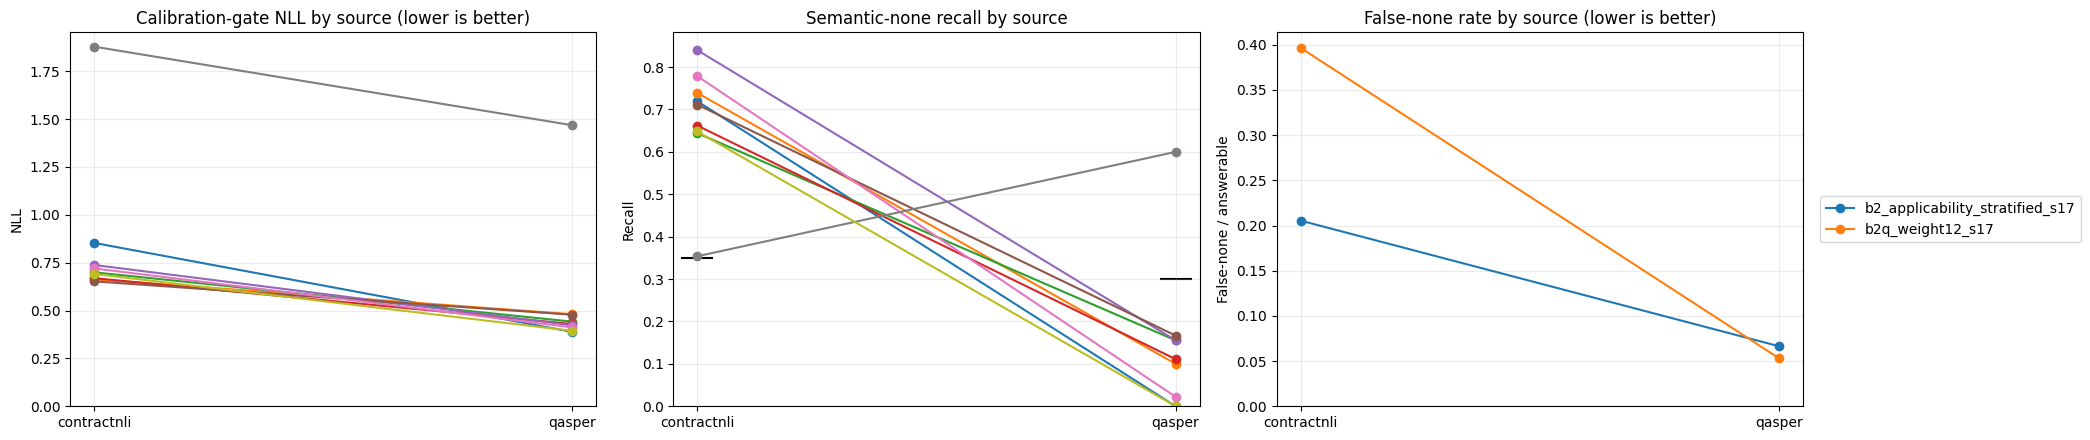

Saved Phase 4B.2 comparison snapshot: /content/drive/MyDrive/Colab Notebooks/OpenKind_Phase4B2_StateQuery_Model_Comparison_results/20260921T013558Z/comparison_snapshot_20260922T115817Z.json


In [10]:
import matplotlib.pyplot as plt

comparison_rows = []

def append_metric_rows(model_name, metrics_by_source, kind):
    for source_name, metrics in metrics_by_source.items():
        comparison_rows.append({
            "model": model_name,
            "kind": kind,
            "source": source_name,
            "n": metrics.get("n"),
            "accuracy": metrics.get("accuracy"),
            "balanced_accuracy": metrics.get("balanced_accuracy"),
            "macro_f1": metrics.get("macro_f1"),
            "nll": metrics.get("nll"),
            "brier": metrics.get("brier"),
            "ece15": metrics.get("ece15"),
            "semantic_none_n": metrics.get("semantic_none_n"),
            "semantic_none_true_positive": metrics.get(
                "semantic_none_true_positive"
            ),
            "semantic_none_false_positive": metrics.get(
                "semantic_none_false_positive"
            ),
            "predicted_none_n": metrics.get("predicted_none_n"),
            "semantic_none_recall": metrics.get("semantic_none_recall"),
            "semantic_none_precision": metrics.get("semantic_none_precision"),
            "answerable_n": metrics.get("answerable_n"),
            "answerable_accuracy": metrics.get("answerable_accuracy"),
            "answerable_non_none_recall": metrics.get(
                "answerable_non_none_recall"
            ),
            "false_none_rate": metrics.get("false_none_rate"),
            "applicability_balanced_accuracy": metrics.get(
                "applicability_balanced_accuracy"
            ),
        })

append_metric_rows(
    "historical_reference",
    BASE_NONFINAL["reference_by_source"],
    "baseline",
)
append_metric_rows(
    "phase4a1_b1_original",
    BASE_NONFINAL["custom_by_source"],
    "baseline",
)

variant_reports = []
for phase_kind, root in (
    ("phase4a2", PHASE4A2_COMPARISON_ROOT),
    ("phase4b2", COMPARISON_ROOT),
):
    if not root.is_dir():
        continue
    for candidate in sorted(root.iterdir()):
        report_path = candidate / "NONFINAL_EVALUATION.json"
        contract_path = candidate / "EXPERIMENT_CONTRACT.json"
        if not report_path.is_file() or not contract_path.is_file():
            continue
        report = read_json(report_path)
        experiment = read_json(contract_path)
        if report.get("experiment_sha256") != experiment.get("experiment_sha256"):
            raise RuntimeError(f"Report/contract mismatch in {candidate}")
        if report.get("final_opened") is not False:
            raise RuntimeError(f"Final-opened report found in {candidate}")
        append_metric_rows(
            candidate.name,
            report["custom_by_source"],
            phase_kind,
        )
        variant_reports.append(report)

comparison = pd.DataFrame(comparison_rows)
display(
    comparison
    .sort_values(["source", "kind", "model"])
    .reset_index(drop=True)
)

macro_columns = [
    "accuracy", "balanced_accuracy", "macro_f1", "nll",
    "brier", "ece15", "semantic_none_recall",
    "semantic_none_precision", "answerable_accuracy",
    "answerable_non_none_recall", "false_none_rate",
    "applicability_balanced_accuracy",
]
macro = (
    comparison
    .groupby(["model", "kind"], as_index=False)[macro_columns]
    .mean(numeric_only=True)
    .sort_values(["kind", "nll", "model"])
)
display(macro)

if not comparison.empty:
    has_false_none = comparison["false_none_rate"].notna().any()
    panel_count = 3 if has_false_none else 2
    figure, axes = plt.subplots(
        1,
        panel_count,
        figsize=(7 * panel_count, 4.5),
    )
    axes = np.atleast_1d(axes)
    for model_name, group in comparison.groupby("model"):
        group = group.sort_values("source")
        axes[0].plot(
            group["source"],
            group["nll"],
            marker="o",
            label=model_name,
        )
        axes[1].plot(
            group["source"],
            group["semantic_none_recall"],
            marker="o",
            label=model_name,
        )
        if has_false_none and group["false_none_rate"].notna().any():
            diagnostic = group.dropna(subset=["false_none_rate"])
            axes[2].plot(
                diagnostic["source"],
                diagnostic["false_none_rate"],
                marker="o",
                label=model_name,
            )
    axes[0].set_title("Calibration-gate NLL by source (lower is better)")
    axes[0].set_ylabel("NLL")
    axes[1].set_title("Semantic-none recall by source")
    axes[1].set_ylabel("Recall")
    for source_name, floor in CFG["minimum_development_none_recall"].items():
        axes[1].scatter(
            [source_name],
            [floor],
            marker="_",
            s=500,
            color="black",
        )
    if has_false_none:
        axes[2].set_title("False-none rate by source (lower is better)")
        axes[2].set_ylabel("False-none / answerable")
    for axis in axes:
        axis.set_ylim(bottom=0)
        axis.grid(alpha=0.25)
    axes[-1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
    plt.tight_layout()
    plt.show()

if variant_reports:
    snapshot = {
        "schema": "openkind-phase4b2-comparison-snapshot/v1",
        "created_at_utc": datetime.now(timezone.utc).isoformat(),
        "base_run_id": BASE_RUN_ID,
        "models": sorted(comparison["model"].unique()),
        "rows": comparison.to_dict("records"),
        "source_macro": macro.to_dict("records"),
        "final_opened": False,
    }
    stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
    snapshot_path = COMPARISON_ROOT / f"comparison_snapshot_{stamp}.json"
    if not snapshot_path.exists():
        atomic_json(snapshot, snapshot_path)
    print("Saved Phase 4B.2 comparison snapshot:", snapshot_path)
else:
    print("No comparison report is available yet.")


## 11. Final split barrier and next-run handoff

This notebook ends after the non-final comparison. There is intentionally no `open_final` flag and no final-evaluation cell.

After `b2_applicability_stratified_s17` completes:

1. require every development recall floor and false-none ceiling;
2. inspect the untouched calibration gate per source rather than relying on source macro;
3. run seeds 42 and 123 only if seed 17 clears the dual gates and preserves proper scores;
4. if seed 17 fails, preserve the result and move to representation/supervision changes rather than another scalar or threshold sweep;
5. open final only in a separate confirmatory notebook after model and numerical gates are frozen.


In [11]:
def open_final_split(*args, **kwargs):
    raise PermissionError(
        "Final evaluation is intentionally unavailable in this Phase 4B.2 follow-on. "
        "Create a separate post-selection confirmatory notebook with frozen gates."
    )

if store is not None and "final" in store.accessed_splits:
    raise AssertionError("Final split was accessed.")
if REPORT is not None and REPORT.get("final_opened") is not False:
    raise AssertionError("Non-final report has an invalid final status.")

if REPORT is not None:
    selection = REPORT["selected_development"]
    print("Selected development eligibility:", selection["eligible"])
    print("Recall deficits:", selection["none_recall_deficits"])
    print("False-none excesses:", selection["false_none_excesses"])
    print("Calibration-gate diagnostics:", REPORT["custom_by_source"])
    if selection["eligible"]:
        print(
            "Development dual gates passed. Review every calibration-gate source "
            "before deciding whether to run seeds 42 and 123."
        )
    else:
        print(
            "Development dual gates failed. Do not replicate this arm; preserve it "
            "and redesign representation or supervision."
        )

print(
    "Final remains closed. The non-final comparison is the terminal action in this notebook."
)


Selected development eligibility: False
Recall deficits: {'contractnli': 0.0, 'qasper': 0.12300884955752212}
False-none excesses: {'contractnli': 0.0, 'qasper': 0.0}
Calibration-gate diagnostics: {'contractnli': {'n': 1207, 'accuracy': 0.6901408450704225, 'balanced_accuracy': 0.6175107919665831, 'macro_f1': 0.6398696268981164, 'nll': 0.6997437106280499, 'brier': 0.4269782083192719, 'ece15': 0.05082436341733704, 'semantic_none_n': 506, 'semantic_none_true_positive': 326, 'semantic_none_false_negative': 180, 'semantic_none_false_positive': 144, 'predicted_none_n': 470, 'semantic_none_recall': 0.6442687747035574, 'semantic_none_precision': 0.6936170212765957, 'answerable_n': 701, 'answerable_accuracy': 0.7232524964336662, 'answerable_non_none_recall': 0.7945791726105563, 'false_none_rate': 0.20542082738944364, 'applicability_balanced_accuracy': 0.7194239736570569}, 'qasper': {'n': 692, 'accuracy': 0.8323699421965318, 'balanced_accuracy': 0.5445551864156515, 'macro_f1': 0.5504480286738351,